In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import xarray as xr
# import cmocean.cm as cmocean
import glob
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.path as mpath
import matplotlib.colors as col
from netCDF4 import Dataset
import cmocean as cmo


import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

figdir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/'

In [2]:
import intake
from access_nri_intake.source.builders import AccessOm2Builder


In [3]:
client = Client(threads_per_worker=1)
client.dashboard_link

'/proxy/46321/status'

### updating with intake catalog:

In [14]:
# add experiments to my own intake:

# - control:
path_ctrl = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath"

# - basal No Gade: GPC029 (Basal)   
path_noBG = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb'

# - basal Gade: GPC023 (Basal_LH)   
path_BG = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb'

# - basal Gade Brine: GPC062 (Basal_LH_Brine)    
path_BGB = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine'

### SOFIA meltwater perturbation expts:
# - control:
path_ctrl_sofia = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_sofia_ssp126"

# - basal No Gade: GPC029 (Basal)   
path_noBG_sofia = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_sofia_ssp126"

# - basal Gade Brine: GPC062 (Basal_LH_Brine)    
path_BGB_sofia = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_ssp126"

path_ctrl_antwater = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_sofia_antwater"
path_BGB_antwater = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_antwater"

# new control runs with Gadel line:
path_ctrl_BG = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_Gade"
path_ctrl_BG_antwater = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_Gade_sofia_antwater"
path_ctrl_antwater_BG = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_sofia_antwater_Gade"


#### building datastore for each experiment:

In [15]:
%%time

builder = AccessOm2Builder(
    path=path_ctrl
).build()

builder.save(
    name="DSW_control", 
    description="Datastore for ACCESS-OM2 ryf9091 DSW control",
)


builder = AccessOm2Builder(
    path=path_noBG
).build()

builder.save(
    name="Basal", 
    description="Datastore for ACCESS-OM2 ryf9091 Basal",
)

builder = AccessOm2Builder(
    path=path_BG,
).build()

builder.save(
    name="Basal_LH", 
    description="Datastore for ACCESS-OM2 ryf9091 Basal_LH",
)

builder = AccessOm2Builder(
    path=path_BGB,
).build()

builder.save(
    name="Basal_LH_Brine", 
    description="Datastore for ACCESS-OM2 ryf9091 Basal_LH_Brine",
)


builder = AccessOm2Builder(
    path=path_ctrl_sofia
).build()

builder.save(
    name="DSW_control_sofia", 
    description="Datastore for ACCESS-OM2 ryf9091 SOFIA control (mbath21)",
)


builder = AccessOm2Builder(
    path=path_noBG_sofia
).build()

builder.save(
    name="Basal_sofia", 
    description="Datastore for ACCESS-OM2 ryf9091 SOFIA Basal rep.",
)


builder = AccessOm2Builder(
    path=path_BGB_sofia
).build()

builder.save(
    name="Basal_LH_Brine_sofia", 
    description="Datastore for ACCESS-OM2 ryf9091 SOFIA Basal_LH_Brine rep.",
)


builder = AccessOm2Builder(
    path=path_ctrl_antwater
).build()

builder.save(
    name="DSW_control_antwater", 
    description="Datastore for ACCESS-OM2 ryf9091 SOFIA Antwater control (mbath21)",
)


builder = AccessOm2Builder(
    path=path_BGB_antwater
).build()

builder.save(
    name="Basal_LH_Brine_antwater", 
    description="Datastore for ACCESS-OM2 ryf9091 SOFIA Antwater Basal_LH_Brine",
)


builder = AccessOm2Builder(
    path=path_ctrl_BG
).build()

builder.save(
    name="DSW_control_LH", 
    description="Datastore for ACCESS-OM2 ryf9091 control + Antwater applying Gade line (all runoff)",
)


builder = AccessOm2Builder(
    path=path_ctrl_BG_antwater
).build()

builder.save(
    name="DSW_control_LH_antwater", 
    description="Datastore for ACCESS-OM2 ryf9091 control applying Gade line only for Antwater anomaly",
)


builder = AccessOm2Builder(
    path=path_ctrl_antwater_BG
).build()

builder.save(
    name="DSW_control_antwater_LH", 
    description="Datastore for ACCESS-OM2 ryf9091 control applying Gade line only for Antwater anomaly",
)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:38: UserWarning: An error occurred while loading the ERDDAP data fetcher, it will not be available !
<class 'ImportError'>
cannot import name '_quote_string_constraints' from 'erddapy.erddapy' (/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/erddapy/erddapy.py)
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:50: UserWarning: An error occurred while loading the ArgoVis data fetcher, it will not be available !
<class 'ImportError'>
cannot import name '_quote_string_constraints' from 'erddapy.erddapy' (/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/erddapy/erddapy.py)
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:66: UserWarning: An error occurred while loadi

Successfully wrote ESM catalog json file to: file:///home/581/fbd581/DSW_control.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal_LH.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal_LH_Brine.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/DSW_control_sofia.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal_sofia.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal_LH_Brine_sofia.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/DSW_control_antwater.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal_LH_Brine_antwater.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/DSW_control_LH.json
Successfully wrote ESM catalog json file to: file:///home/581/fbd581/DSW_control_LH_antwater.json
Successfu

#### loading intake datastore for individual experiments:

In [16]:
cat = intake.open_esm_datastore(
    "./DSW_control.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_noBG = intake.open_esm_datastore(
    "./Basal.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_BG = intake.open_esm_datastore(
    "./Basal_LH.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_BGB = intake.open_esm_datastore(
    "./Basal_LH_Brine.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_sofia = intake.open_esm_datastore(
    "./DSW_control_sofia.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important 
)

cat_noBG_sofia = intake.open_esm_datastore(
    "./Basal_sofia.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_BGB_sofia = intake.open_esm_datastore(
    "./Basal_LH_Brine_sofia.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_antwater = intake.open_esm_datastore(
    "./DSW_control_antwater.json",
    columns_with_iterables=["variable"] # This is important
)

cat_BGB_antwater = intake.open_esm_datastore(
    "./Basal_LH_Brine_antwater.json",
    columns_with_iterables=["variable"] # This is important
)

cat_SSStest = intake.open_esm_datastore(
    "./DSW_control_noSSSrest.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_ctrlBG = intake.open_esm_datastore(
    "./DSW_control_LH.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_ctrlBG_antwater = intake.open_esm_datastore(
    "./DSW_control_LH_antwater.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

cat_ctrl_antwater_BG = intake.open_esm_datastore(
    "./DSW_control_antwater_LH.json",
    columns_with_iterables=["variable",
                            "variable_long_name",
                            "variable_standard_name",
                            "variable_cell_methods",
                            "variable_units"] # This is important
)

#### load area and layer thickness:

In [17]:
%%time
# Make sure these match the available restarts:
start_time='1917-01-01'
end_time='1919-12-31'
# start_time='1900-01-01'
# end_time='1901-12-31'

lat_slice  = slice(-80,-59)


CPU times: user 4 μs, sys: 10 μs, total: 14 μs
Wall time: 20.7 μs


In [18]:
## load area and ht (for plotting):
d1 = cat.search(variable="area_t",path='/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output000/ocean/ocean_grid.nc').to_dask()
oc_grd = d1.sel(yt_ocean=lat_slice)
area_t = oc_grd.area_t

d2 = cat.search(variable="ht",path='/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output000/ocean/ocean_grid.nc').to_dask()
oc_grd = d2.isel(yt_ocean=lat_slice)
ht = oc_grd.ht

land_mask = np.squeeze(ht)*0
land_mask_fld = land_mask.fillna(1)
land_mask_fld = np.where(land_mask_fld==1,land_mask_fld,np.nan)
land_mask_masked = np.ma.masked_where((land_mask_fld==0),land_mask_fld)

# make land go all the way to -90S:
land_mask_lat = ht.yt_ocean.values
land_mask_lat[0] = -90

fontsize=15

### Load cross-1000m transport for plots:

In [19]:
# !ls /g/data/e14/fbd581/Basal_Pedro_project/updated_git_basal_mom5-collaborative/basal_mom5-collaborative-project/notebooks/cross_contour/
!ls /g/data/e14/fbd581/Basal_Pedro_project/updating_github_repo/basal_mom5-collaborative-project/notebooks/cross_contour/

PBS-script-code
basal_gade_brine_antwater_vol_trans_across_contour_binned_last_3yr.nc
basal_gade_brine_ssp126_vol_trans_across_contour_binned_last_3yr.nc
basal_gade_brine_vol_trans_across_contour_binned_last_3yr.nc
basal_nogade_ssp126_vol_trans_across_contour_binned_last_3yr.nc
basal_nogade_vol_trans_across_contour_binned_last_3yr.nc
control_antwater_gade_vol_trans_across_contour_binned_last_3yr.nc
control_antwater_vol_trans_across_contour_binned_last_3yr.nc
control_gade_antwater_vol_trans_across_contour_binned_last_3yr.nc
control_gade_vol_trans_across_contour_binned_last_3yr.nc
control_ssp126_vol_trans_across_contour_binned_last_3yr.nc
control_vol_trans_across_contour_binned_last_3yr.nc
old
plot_volume_transports-combined-plot.ipynb
plot_volume_transports-combined-plot_SOFIA.ipynb
plot_volume_transports-combined-plot_SOFIA_Antwater_updated.ipynb


In [20]:
%%time

## 1 = control
## 2 = control antwater
## 8 = control ssp126
## 3 - control_gade
## 4 - control_gade antwater
## 5 - control antwater_gade
## 6 - BGB
## 7 - BGB antwater
## 9 - BGB ssp126

## these are the 'wrong' runs with 30% extra MW:
# save_dir = '/g/data/e14/fbd581/Basal_Pedro_project/updated_git_basal_mom5-collaborative/basal_mom5-collaborative-project/notebooks/cross_contour/'

## these are the 'correct' runs with the precise amount of MW for Antwater expts:
save_dir = '/g/data/e14/fbd581/Basal_Pedro_project/updating_github_repo/basal_mom5-collaborative-project/notebooks/cross_contour/'

array1 = xr.open_dataset(save_dir+'control_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
array2 = xr.open_dataset(save_dir+'control_antwater_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
array3 = xr.open_dataset(save_dir+'control_gade_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
array4 = xr.open_dataset(save_dir+'control_gade_antwater_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
array5 = xr.open_dataset(save_dir+'control_antwater_gade_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
array6 = xr.open_dataset(save_dir+'basal_gade_brine_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
array7 = xr.open_dataset(save_dir+'basal_gade_brine_antwater_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr

array8 = xr.open_dataset(save_dir+'control_ssp126_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
array9 = xr.open_dataset(save_dir+'basal_gade_brine_ssp126_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr

array10 = xr.open_dataset(save_dir+'basal_nogade_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
array11 = xr.open_dataset(save_dir+'basal_nogade_ssp126_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr



CPU times: user 533 ms, sys: 393 ms, total: 926 ms
Wall time: 1.05 s


#### read contours and calculate other metrics for the cross-slope transport:

In [21]:
### Load Adele's isobath contour
lat_range  = slice(-90,-59)
isobath_depth = 1000
##outfile = '/g/data/x77/cy8964/Post_Process/access-om2'+'/Antarctic_slope_contour_'+str(isobath_depth)+'m.npz'
outfile = '/g/data/e14/fbd581/basal_mom5-collaborative-project/Antarctic_slope_contour_'+str(isobath_depth)+'m.npz'
data = np.load(outfile)
mask_y_transport = data['mask_y_transport']
mask_x_transport = data['mask_x_transport']

## PS: for some reason, the lines below sometimes (=often) doesn't run at first attempt, often needing to run a few attempts before it works. -> should I report this??

# ht = cat.search(variable='ht', file_id='ocean.fx.xt_ocean:3600.xu_ocean:3600.yt_ocean:2700.yu_ocean:2700').to_dask(xarray_open_kwargs={'decode_timedelta':False})#,'chunks' :{'grid_yt_ocean' : 600,'grid_xt_ocean' : 800,}})
# ht = ht['ht'].sel(yt_ocean=lat_range)


In [22]:
xt_ocean = cat.search(variable='xt_ocean', file_id='ocean.fx.xt_ocean:3600.xu_ocean:3600.yt_ocean:2700.yu_ocean:2700').to_dask()
xt_ocean = xt_ocean['xt_ocean']

In [23]:
yt_ocean = cat.search(variable='yt_ocean', file_id='ocean.fx.xt_ocean:3600.xu_ocean:3600.yt_ocean:2700.yu_ocean:2700').to_dask(xarray_open_kwargs={'decode_timedelta':True})
yt_ocean = yt_ocean['yt_ocean']
yt_ocean = yt_ocean.sel(yt_ocean=lat_range)


In [24]:
def shelf_mask_isobath(var):
    '''
    Masks ACCESS-OM2-01 variables by the region polewards of the 1000m isobath as computed using 
    a script contributed by Adele Morrison.
    Only to be used with ACCESS-OM2-0.1 output!
    '''
    contour_file = np.load('/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz')
    
    shelf_mask = contour_file['contour_masked_above']
    yt_ocean = contour_file['yt_ocean']
    xt_ocean = contour_file['xt_ocean']
    
    # in this file the points along the isobath are given a positive value, the points outside (northwards) 
    # of the isobath are given a value of -100 and all the points on the continental shelf have a value of 0 
    # so we mask for the 0 values 
    shelf_mask[np.where(shelf_mask!=0)] = np.nan
    shelf_mask = shelf_mask+1
    shelf_map = np.nan_to_num(shelf_mask)
    shelf_mask = xr.DataArray(shelf_mask, coords = [('yt_ocean', yt_ocean), ('xt_ocean', xt_ocean)])
    shelf_map = xr.DataArray(shelf_map, coords = [('yt_ocean', yt_ocean), ('xt_ocean', xt_ocean)])
    
    # then we want to multiply the variable with the mask so we need to account for the shape of the mask. 
    # The mask uses a northern cutoff of 59S.
    masked_var = var.sel(yt_ocean = slice(-90, -59.03)) * shelf_mask
    return masked_var, shelf_map

In [25]:
## PS: for some reason, the lines below sometimes (=often) doesn't run at first attempt, often needing to run a few attempts before it works. -> should I report this??
## same here!!

yu_ocean = cat.search(variable='yu_ocean', file_id='ocean.fx.xt_ocean:3600.xu_ocean:3600.yt_ocean:2700.yu_ocean:2700').to_dask(xarray_open_kwargs={'decode_timedelta':True})
yu_ocean = yu_ocean.sel(yu_ocean=lat_range)

xu_ocean = cat.search(variable='xu_ocean', file_id='ocean.fx.xt_ocean:3600.xu_ocean:3600.yt_ocean:2700.yu_ocean:2700').to_dask(xarray_open_kwargs={'decode_timedelta':True})


In [26]:
mask_y_transport = data['mask_y_transport']
mask_x_transport = data['mask_x_transport']
mask_y_transport_numbered = data['mask_y_transport_numbered']
mask_x_transport_numbered = data['mask_x_transport_numbered']

mask_x_transport = xr.DataArray(mask_x_transport, coords = [yt_ocean['yt_ocean'], xu_ocean['xu_ocean']], dims=['y_ocean', 'x_ocean'])
mask_y_transport = xr.DataArray(mask_y_transport, coords = [yu_ocean['yu_ocean'], xt_ocean['xt_ocean']], dims=['y_ocean', 'x_ocean'])
mask_x_transport_numbered = xr.DataArray(mask_x_transport_numbered, coords = [yt_ocean['yt_ocean'], xu_ocean['xu_ocean']], dims=['y_ocean', 'x_ocean'])
mask_y_transport_numbered = xr.DataArray(mask_y_transport_numbered, coords = [yu_ocean['yu_ocean'], xt_ocean['xt_ocean']], dims=['y_ocean', 'x_ocean'])

# stack contour data into 1d:
mask_x_numbered_1d = mask_x_transport_numbered.stack(contour_index = ['y_ocean', 'x_ocean'])
mask_x_numbered_1d = mask_x_numbered_1d.where(mask_x_numbered_1d > 0, drop = True)
mask_y_numbered_1d = mask_y_transport_numbered.stack(contour_index = ['y_ocean', 'x_ocean'])
mask_y_numbered_1d = mask_y_numbered_1d.where(mask_y_numbered_1d > 0, drop = True)
contour_ordering = xr.concat((mask_x_numbered_1d,mask_y_numbered_1d), dim = 'contour_index')
contour_ordering = contour_ordering.sortby(contour_ordering)
contour_index_array = np.arange(1,len(contour_ordering)+1)

# get lat and lon along contour, useful for plotting later:
lat_along_contour = contour_ordering.y_ocean
lon_along_contour = contour_ordering.x_ocean
# don't need the multi-index anymore, replace with contour count
lat_along_contour.coords['contour_index'] = contour_index_array
lon_along_contour.coords['contour_index'] = contour_index_array



In [27]:
land_mask = (ht*0).fillna(1)
### yt_ocean = ht.yt_ocean.values
### xt_ocean = ht.xt_ocean.values
ht_shelf , shelf_mask = shelf_mask_isobath(ht)



In [28]:
AdelieW = -280
AdelieE = -200
RossW = -200
RossE = -150
# WAW = -150
# WAE = -65
AmW = -150
AmE = -100
BeW = -100
BeE = -65

WeddellW = -65
WeddellE = 0
PrydzW = 0
PrydzE = 80

basin_indices = np.zeros(7)
for i in np.arange(100,len(lon_along_contour.values)):
    if (basin_indices[1]==0):
        if (lon_along_contour.values[i]>AdelieE):
            basin_indices[1] = lon_along_contour.contour_index.values[i]
    if (basin_indices[2]==0):
        if (lon_along_contour.values[i]>RossE):
            basin_indices[2] = lon_along_contour.contour_index.values[i]
    if (basin_indices[3]==0):
        if (lon_along_contour.values[i]>AmE):
            basin_indices[3] = lon_along_contour.contour_index.values[i]
    if (basin_indices[4]==0):
        if (lon_along_contour.values[i]>BeE):
            basin_indices[4] = lon_along_contour.contour_index.values[i]
    if (basin_indices[5]==0):
        if lon_along_contour.values[i]>WeddellE:
            basin_indices[5] = lon_along_contour.contour_index.values[i]
    if (basin_indices[6]==0):
        if (lon_along_contour.values[i]>PrydzE):
            basin_indices[6] = lon_along_contour.contour_index.values[i]
# basin_indices

Adelie = slice(basin_indices[0],basin_indices[1])
Ross = slice(basin_indices[1],basin_indices[2])
Am = slice(basin_indices[2],basin_indices[3])
Be = slice(basin_indices[3],basin_indices[4])
Weddell = slice(basin_indices[4], basin_indices[5])
Prydz = slice(basin_indices[5],6002)

In [29]:
## 1 = control
## 2 = control antwater
## 8 = control ssp126
## 3 - control_gade
## 4 - control_gade antwater
## 5 - control antwater_gade
## 6 - BGB
## 7 - BGB antwater
## 9 - BGB ssp126
## 10 - basalNoGade 
## 11 - basalNoGade ssp126

# Define your arrays and their names
arrays = {
    "control": array1,
    "control_antwater": array2,
    "control_gade": array3,
    "control_gade_antwater": array4,
    "control_antwater_gade": array5,
    "BGB": array6,
    "BGB_antwater": array7,
    "control_ssp126": array8,
    "BGB_ssp126": array9,
    "basal_noBG": array10,
    "basal_noBG_ssp126": array11,
}

# Define regions and readable names
regions = {
    "Adelie": Adelie,
    "Ross": Ross,
    "Weddell": Weddell,
    "Prydz": Prydz,
}

# Dictionary to store all results
results = {}

for name, arr in arrays.items():

    # Create sub-dictionary for this array
    results[name] = {}

    # ---- TOTAL (no region selection) ----
    b = (arr.isel(variable=0)/1e6).sum("contour_index")
    bb = b.sum("isopycnal_bins") - b.cumsum("isopycnal_bins")

    results[name]["total"] = {"bb": bb}

    # ---- REGION-SPECIFIC ----
    for region_name, region_idx in regions.items():

        b_reg = (arr.isel(variable=0)/1e6).sel(contour_index=region_idx).sum("contour_index")
        bb_reg = b_reg.sum("isopycnal_bins") - b_reg.cumsum("isopycnal_bins")

        results[name][region_name] = {"bb": bb_reg}


In [30]:
# ### Example for bar plots (from Fig. 1):
# # Add inset bar plots
# for region, pos in positions.items():
#     ax_inset = inset_axes(ax_map, width=pos[2], height=pos[3],
#                           loc='lower left', bbox_to_anchor=(pos[0], pos[1], pos[2], pos[3]),
#                           bbox_transform=ax_map.transAxes)
#     ax_inset.bar(experiments, data_CST[region], color=['blue','cornflowerblue', 'skyblue','chocolate', 'darkorange', 'sandybrown'])#,
#                 # hatch=['','/','.','','/','.'])
#     if region=='Weddell':
#         ax_inset.set_title(region, color='limegreen', fontsize=14)
#     elif region=='Prydz':
#         ax_inset.set_title(region, color='dodgerblue', fontsize=14)
#     elif region=='Mertz':
#         ax_inset.set_title(region, color='lightsalmon', fontsize=14)
#     elif region=='Ross':
#         ax_inset.set_title(region, color='gold', fontsize=14)
#     ax_inset.set_ylabel('Cross-slope \n transp. (Sv)', fontsize=10)
#     ax_inset.tick_params(axis='x', labelsize=10, rotation=90)
#     ax_inset.tick_params(axis='y', labelsize=10, rotation=90)
#     # ax_inset.set_xticks(rotation=45, ha="right")


In [31]:
results['control_antwater']['Adelie']["bb"].isel(isopycnal_bins=slice(55,-1))[0].values



array(0.07356858)

In [32]:
## getting results for bar plot with LH runs:

#adelie
results['BGB_antwater']['Adelie']["bb"].isel(isopycnal_bins=slice(55,-1))[0].values
iadelie=55
#ross
results['BGB_antwater']['Ross']["bb"].isel(isopycnal_bins=slice(68,-1))[0].values
iross=68
#weddell
results['BGB_antwater']['Weddell']["bb"].isel(isopycnal_bins=slice(58,-1))[0].values
iweddell=58
#prydz
results['BGB_antwater']['Prydz']["bb"].isel(isopycnal_bins=slice(51,-1))[0].values
iprydz=51

# define temporary variables to facilitate plotting:

# 1st per region
adelie_sfc_antw_anom = results['control_antwater']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values - results['control']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values
adelie_sfc_lh_antw_anom = results['control_gade_antwater']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values - results['control_gade']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values
adelie_sfc_antw_lh_anom = results['control_antwater_gade']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values - results['control']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values
adelie_basal_lh_antw_anom = results['BGB_antwater']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values - results['BGB']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values

ross_sfc_antw_anom = results['control_antwater']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values - results['control']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values
ross_sfc_lh_antw_anom = results['control_gade_antwater']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values - results['control_gade']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values
ross_sfc_antw_lh_anom = results['control_antwater_gade']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values - results['control']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values
ross_basal_lh_antw_anom = results['BGB_antwater']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values - results['BGB']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values

weddell_sfc_antw_anom = results['control_antwater']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values - results['control']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values
weddell_sfc_lh_antw_anom = results['control_gade_antwater']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values - results['control_gade']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values
weddell_sfc_antw_lh_anom = results['control_antwater_gade']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values - results['control']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values
weddell_basal_lh_antw_anom = results['BGB_antwater']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values - results['BGB']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values

prydz_sfc_antw_anom = results['control_antwater']['Prydz']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values - results['control']['Prydz']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values
prydz_sfc_lh_antw_anom = results['control_gade_antwater']['Prydz']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values - results['control_gade']['Prydz']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values
prydz_sfc_antw_lh_anom = results['control_antwater_gade']['Prydz']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values - results['control']['Prydz']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values
prydz_basal_lh_antw_anom = results['BGB_antwater']['Prydz']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values - results['BGB']['Prydz']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values

# 2nd calculate the total (sum of each DSW formation region) and estimate the total anomaly:

total_control = results['control']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values + \
                results['control']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values + \
                results['control']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values + \
                results['control']['Adelie']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values

total_control_gade = results['control_gade']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values + \
                results['control_gade']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values + \
                results['control_gade']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values + \
                results['control_gade']['Adelie']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values

total_BGB = results['BGB']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values + \
                results['BGB']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values + \
                results['BGB']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values + \
                results['BGB']['Adelie']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values

total_control_antwater = results['control_antwater']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values + \
                            results['control_antwater']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values + \
                            results['control_antwater']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values + \
                            results['control_antwater']['Adelie']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values


total_control_gade_antwater = results['control_gade_antwater']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values + \
                                results['control_gade_antwater']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values + \
                                results['control_gade_antwater']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values + \
                                results['control_gade_antwater']['Adelie']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values

total_control_antwater_gade = results['control_antwater_gade']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values + \
                                results['control_antwater_gade']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values + \
                                results['control_antwater_gade']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values + \
                                results['control_antwater_gade']['Adelie']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values


total_BGB = results['BGB']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values + \
                results['BGB']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values + \
                results['BGB']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values + \
                results['BGB']['Adelie']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values

total_BGB_antwater = results['BGB_antwater']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values + \
                        results['BGB_antwater']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values + \
                        results['BGB_antwater']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values + \
                        results['BGB_antwater']['Adelie']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values

total_sfc_antw_anom = total_control_antwater - total_control
total_sfc_lh_antw_anom = total_control_gade_antwater - total_control_gade
total_sfc_antw_lh_anom = total_control_antwater_gade - total_control
total_basal_lh_antw_anom = total_BGB_antwater - total_BGB

## Load DSW mask (based on control SWMT)

In [33]:
ds_masks = xr.open_dataset("/g/data/e14/fbd581/basal_mom5-collaborative-project/dsw_masks.nc")
# Extract variables
dsw_mask = ds_masks["dsw_mask"]
swmt_dsw_only = ds_masks["swmt_dsw_only"]

In [34]:
# Ensure boolean type after loading
dsw_mask = dsw_mask.astype(bool)


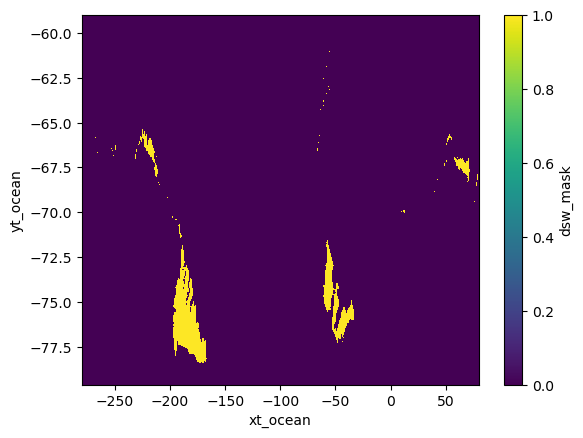

In [35]:
dsw_mask.plot()

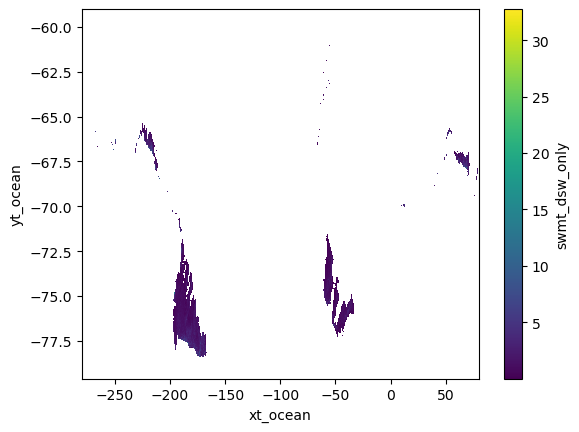

In [36]:
swmt_dsw_only.plot()

### Load Salinity from all experiments

In [37]:
# Obtain salinity for all experiments: (!!! again this section takes a lot of patience to run, after many attemps, line by line. Intake is just sh*t or I'm doing anything wrong???)

s1 = cat.search(variable="salt",frequency='1mon').to_dask()
s2 = cat_noBG.search(variable="salt",frequency='1mon').to_dask()
s3 = cat_BGB.search(variable="salt",frequency='1mon').to_dask()
s1s = cat_sofia.search(variable="salt",frequency='1mon').to_dask()
s2s = cat_noBG_sofia.search(variable="salt",frequency='1mon').to_dask()
s3s = cat_BGB_sofia.search(variable="salt",frequency='1mon').to_dask()

s1a = cat_antwater.search(variable="salt",frequency='1mon').to_dask()
s3a = cat_BGB_antwater.search(variable="salt",frequency='1mon').to_dask()

s1b = cat_ctrlBG.search(variable="salt",frequency='1mon').to_dask()
s1a_b = cat_ctrlBG_antwater.search(variable="salt",frequency='1mon').to_dask()
s1a_c = cat_ctrl_antwater_BG.search(variable="salt",frequency='1mon').to_dask()

# select time period (1917-1920), SO only (yt_ocean <-59) and bottom values:
time_slice = slice(start_time,end_time)
lat_slice = slice(-79.59,-58.98)
wetS = s1.isel(time=0).notnull()  # (st_ocean, yt_ocean, xt_ocean) of booleans

s1_bottom = s1.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)   
s1s_bottom = s1s.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)   
s1a_bottom = s1a.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)   
s1b_bottom = s1b.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)   
s1a_b_bottom = s1a_b.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)   
s1a_c_bottom = s1a_c.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)

s2_bottom = s2.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)   
s2s_bottom = s2s.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)   

s3_bottom = s3.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)   
s3s_bottom = s3s.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)   
s3a_bottom = s3a.where(wetS).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)   


In [38]:
# %%time
# ## load -->> takes ages, doing it after masking;
# s1_bottom.load()
# s1s_bottom.load()
# s1a_bottom.load()
# s1b_bottom.load()
# s1a_b_bottom.load()
# s1a_c_bottom.load()
# s2_bottom.load()
# s2s_bottom.load()
# s3_bottom.load()
# s3s_bottom.load()
# s3a_bottom.load()


In [39]:
# Mask salinity fields
salt_ctrl_dsw = s1_bottom.where(dsw_mask)
salt_ctrl_ssp_dsw = s1s_bottom.where(dsw_mask)
salt_ctrl_antw_dsw = s1a_bottom.where(dsw_mask)

salt_basal_dsw = s2_bottom.where(dsw_mask)
salt_basal_ssp_dsw = s2s_bottom.where(dsw_mask)

salt_basalLH_dsw = s3_bottom.where(dsw_mask)
salt_basalLH_ssp_dsw = s3s_bottom.where(dsw_mask)
salt_basalLH_antw_dsw = s3a_bottom.where(dsw_mask)

salt_ctrlLH_dsw = s1b_bottom.where(dsw_mask)
salt_ctrlLH_antw_dsw = s1a_b_bottom.where(dsw_mask)
salt_ctrl_antw_LH_dsw = s1a_c_bottom.where(dsw_mask)


In [40]:
### subregions

# Ross: lon -200:-160, lat -80:-70
salt_ross = salt_ctrl_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))
salt_ross_ssp = salt_ctrl_ssp_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))
salt_ross_antw = salt_ctrl_antw_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))

salt_ross_basal = salt_basal_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))
salt_ross_basal_ssp = salt_ctrl_ssp_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))

salt_ross_basalLH = salt_basalLH_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))
salt_ross_basalLH_ssp = salt_basalLH_ssp_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))
salt_ross_basalLH_antw = salt_basalLH_antw_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))

salt_ross_LH = salt_ctrlLH_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))
salt_ross_LH_antw = salt_ctrlLH_antw_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))
salt_ross_antw_LH = salt_ctrl_antw_LH_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))


In [41]:
# Adelie: lon -230:-210, lat -80:-70
salt_adelie = salt_ctrl_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))
salt_adelie_ssp = salt_ctrl_ssp_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))
salt_adelie_antw = salt_ctrl_antw_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))

salt_adelie_basal = salt_basal_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))
salt_adelie_basal_ssp = salt_ctrl_ssp_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))

salt_adelie_basalLH = salt_basalLH_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))
salt_adelie_basalLH_ssp = salt_basalLH_ssp_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))
salt_adelie_basalLH_antw = salt_basalLH_antw_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))

salt_adelie_LH = salt_ctrlLH_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))
salt_adelie_LH_antw = salt_ctrlLH_antw_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))
salt_adelie_antw_LH = salt_ctrl_antw_LH_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))


In [42]:
# Prydz: lon 58:73, lat -70:-65
salt_prydz = salt_ctrl_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))
salt_prydz_ssp = salt_ctrl_ssp_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))
salt_prydz_antw = salt_ctrl_antw_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))

salt_prydz_basal = salt_basal_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))
salt_prydz_basal_ssp = salt_ctrl_ssp_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))

salt_prydz_basalLH = salt_basalLH_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))
salt_prydz_basalLH_ssp = salt_basalLH_ssp_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))
salt_prydz_basalLH_antw = salt_basalLH_antw_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))

salt_prydz_LH = salt_ctrlLH_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))
salt_prydz_LH_antw = salt_ctrlLH_antw_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))
salt_prydz_antw_LH = salt_ctrl_antw_LH_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))


In [43]:
# Weddell: lon -65:-30, lat -78:-70
salt_weddell = salt_ctrl_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))
salt_weddell_ssp = salt_ctrl_ssp_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))
salt_weddell_antw = salt_ctrl_antw_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))

salt_weddell_basal = salt_basal_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))
salt_weddell_basal_ssp = salt_ctrl_ssp_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))

salt_weddell_basalLH = salt_basalLH_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))
salt_weddell_basalLH_ssp = salt_basalLH_ssp_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))
salt_weddell_basalLH_antw = salt_basalLH_antw_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))

salt_weddell_LH = salt_ctrlLH_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))
salt_weddell_LH_antw = salt_ctrlLH_antw_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))
salt_weddell_antw_LH = salt_ctrl_antw_LH_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))


### Load Temperature from all experiments

In [44]:
t1

NameError: name 't1' is not defined

In [ ]:
# Obtain salinity for all experiments: (!!! again this section takes a lot of patience to run, after many attemps, line by line. Intake is just sh*t or I'm doing anything wrong???)

t1 = cat.search(variable="temp",frequency='1mon').to_dask()
t2 = cat_noBG.search(variable="temp",frequency='1mon').to_dask()
t3 = cat_BGB.search(variable="temp",frequency='1mon').to_dask()
t1s = cat_sofia.search(variable="temp",frequency='1mon').to_dask()
t2s = cat_noBG_sofia.search(variable="temp",frequency='1mon').to_dask()
t3s = cat_BGB_sofia.search(variable="temp",frequency='1mon').to_dask()

t1a = cat_antwater.search(variable="temp",frequency='1mon').to_dask()
t3a = cat_BGB_antwater.search(variable="temp",frequency='1mon').to_dask()

t1b = cat_ctrlBG.search(variable="temp",frequency='1mon').to_dask()
t1a_b = cat_ctrlBG_antwater.search(variable="temp",frequency='1mon').to_dask()
t1a_c = cat_ctrl_antwater_BG.search(variable="temp",frequency='1mon').to_dask()

# select time period (1917-1920), SO only (yt_ocean <-59) and bottom values:
lat_slice = slice(-79.59,-58.98)
wetT = t1.isel(time=0).notnull()  # (st_ocean, yt_ocean, xt_ocean) of booleans

t1_bottom = t1.where(wetT).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)   
t1s_bottom = t1s.where(wetT).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)   
t1a_bottom = t1a.where(wetT).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)   
t1b_bottom = t1b.where(wetT).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)   
t1a_b_bottom = t1a_b.where(wetT).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)   
t1a_c_bottom = t1a_c.where(wetT).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)

t2_bottom = t2.where(wetT).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)   
t2s_bottom = t2s.where(wetT).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)   

t3_bottom = t3.where(wetT).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)   
t3s_bottom = t3s.where(wetT).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)   
t3a_bottom = t3a.where(wetT).ffill("st_ocean").isel(st_ocean=-1).sel(time=time_slice, yt_ocean=lat_slice)   


In [ ]:
# Mask temperature fields
temp_ctrl_dsw = t1_bottom.where(dsw_mask)
temp_ctrl_ssp_dsw = t1s_bottom.where(dsw_mask)
temp_ctrl_antw_dsw = t1a_bottom.where(dsw_mask)

temp_basal_dsw = t2_bottom.where(dsw_mask)
temp_basal_ssp_dsw = t2s_bottom.where(dsw_mask)

temp_basalLH_dsw = t3_bottom.where(dsw_mask)
temp_basalLH_ssp_dsw = t3s_bottom.where(dsw_mask)
temp_basalLH_antw_dsw = t3a_bottom.where(dsw_mask)

temp_ctrlLH_dsw = t1b_bottom.where(dsw_mask)
temp_ctrlLH_antw_dsw = t1a_b_bottom.where(dsw_mask)
temp_ctrl_antw_LH_dsw = t1a_c_bottom.where(dsw_mask)


In [ ]:
### subregions

# Ross: lon -200:-160, lat -80:-70
temp_ross = temp_ctrl_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))
temp_ross_ssp = temp_ctrl_ssp_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))
temp_ross_antw = temp_ctrl_antw_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))

temp_ross_basal = temp_basal_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))
temp_ross_basal_ssp = temp_ctrl_ssp_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))

temp_ross_basalLH = temp_basalLH_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))
temp_ross_basalLH_ssp = temp_basalLH_ssp_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))
temp_ross_basalLH_antw = temp_basalLH_antw_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))

temp_ross_LH = temp_ctrlLH_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))
temp_ross_LH_antw = temp_ctrlLH_antw_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))
temp_ross_antw_LH = temp_ctrl_antw_LH_dsw.sel(xt_ocean=slice(-200,-160), yt_ocean=slice(-80,-70))


In [ ]:
# Adelie: lon -230:-210, lat -80:-70
temp_adelie = temp_ctrl_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))
temp_adelie_ssp = temp_ctrl_ssp_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))
temp_adelie_antw = temp_ctrl_antw_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))

temp_adelie_basal = temp_basal_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))
temp_adelie_basal_ssp = temp_ctrl_ssp_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))

temp_adelie_basalLH = temp_basalLH_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))
temp_adelie_basalLH_ssp = temp_basalLH_ssp_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))
temp_adelie_basalLH_antw = temp_basalLH_antw_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))

temp_adelie_LH = temp_ctrlLH_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))
temp_adelie_LH_antw = temp_ctrlLH_antw_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))
temp_adelie_antw_LH = temp_ctrl_antw_LH_dsw.sel(xt_ocean=slice(-240,-210), yt_ocean=slice(-70,-65))


In [ ]:
# Prydz: lon 58:73, lat -70:-65
temp_prydz = temp_ctrl_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))
temp_prydz_ssp = temp_ctrl_ssp_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))
temp_prydz_antw = temp_ctrl_antw_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))

temp_prydz_basal = temp_basal_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))
temp_prydz_basal_ssp = temp_ctrl_ssp_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))

temp_prydz_basalLH = temp_basalLH_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))
temp_prydz_basalLH_ssp = temp_basalLH_ssp_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))
temp_prydz_basalLH_antw = temp_basalLH_antw_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))

temp_prydz_LH = temp_ctrlLH_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))
temp_prydz_LH_antw = temp_ctrlLH_antw_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))
temp_prydz_antw_LH = temp_ctrl_antw_LH_dsw.sel(xt_ocean=slice(58,73), yt_ocean=slice(-70,-65))


In [ ]:
# Weddell: lon -65:-30, lat -78:-70
temp_weddell = temp_ctrl_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))
temp_weddell_ssp = temp_ctrl_ssp_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))
temp_weddell_antw = temp_ctrl_antw_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))

temp_weddell_basal = temp_basal_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))
temp_weddell_basal_ssp = temp_ctrl_ssp_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))

temp_weddell_basalLH = temp_basalLH_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))
temp_weddell_basalLH_ssp = temp_basalLH_ssp_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))
temp_weddell_basalLH_antw = temp_basalLH_antw_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))

temp_weddell_LH = temp_ctrlLH_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))
temp_weddell_LH_antw = temp_ctrlLH_antw_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))
temp_weddell_antw_LH = temp_ctrl_antw_LH_dsw.sel(xt_ocean=slice(-65,-30), yt_ocean=slice(-78,-70))


#### Checking masks and salinity timeseries:

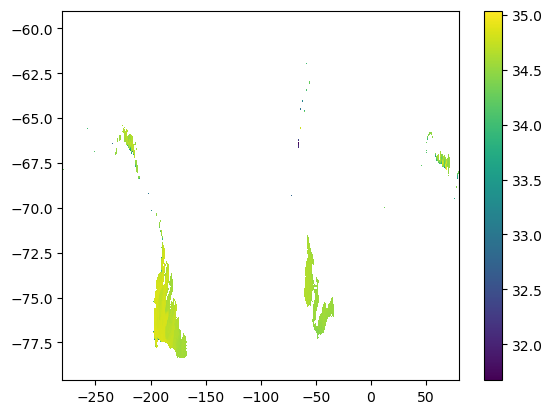

In [42]:
plt.pcolormesh(salt_ctrl_dsw.xt_ocean, salt_ctrl_dsw.yt_ocean, salt_ctrl_dsw.isel(time=0).to_dataarray().squeeze())
plt.colorbar()
# plt.xlim(25,80)

Text(0.5, 1.0, 'Prydz')

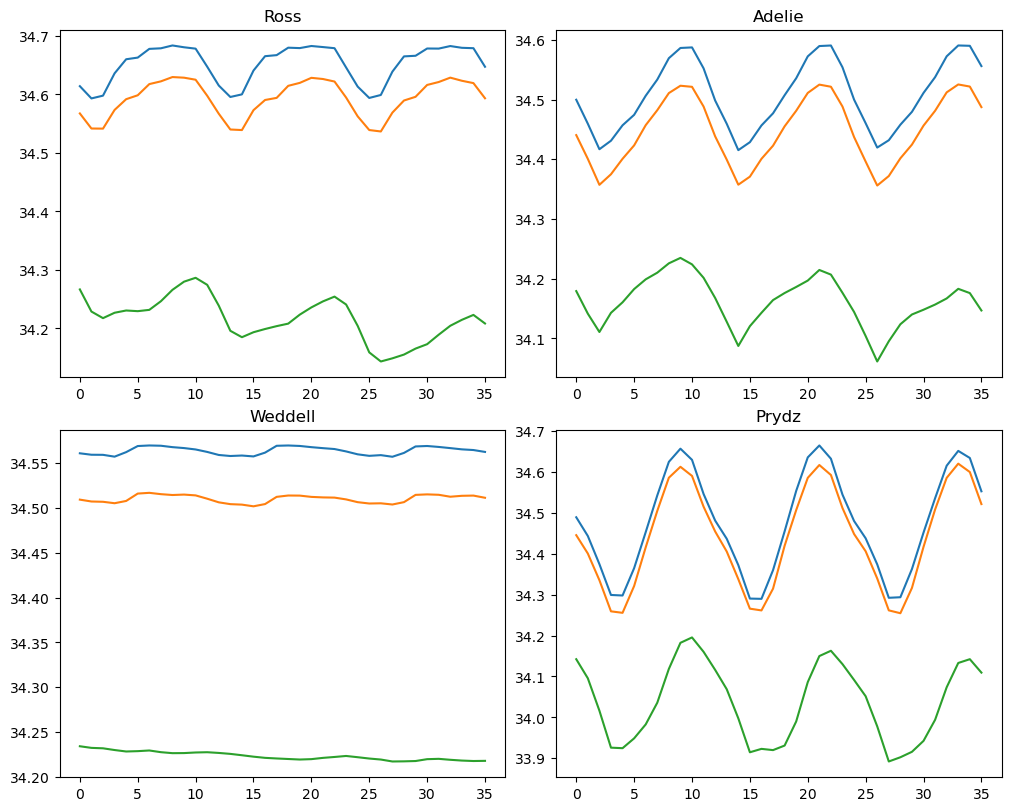

In [43]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), layout="constrained")

ax[0,0].plot(np.nanmean(np.nanmean(salt_ross.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,0].plot(np.nanmean(np.nanmean(salt_ross_ssp.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,0].plot(np.nanmean(np.nanmean(salt_ross_antw.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,0].set_title('Ross')

ax[0,1].plot(np.nanmean(np.nanmean(salt_adelie.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,1].plot(np.nanmean(np.nanmean(salt_adelie_ssp.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,1].plot(np.nanmean(np.nanmean(salt_adelie_antw.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,1].set_title('Adelie')

ax[1,0].plot(np.nanmean(np.nanmean(salt_weddell.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,0].plot(np.nanmean(np.nanmean(salt_weddell_ssp.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,0].plot(np.nanmean(np.nanmean(salt_weddell_antw.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,0].set_title('Weddell')

ax[1,1].plot(np.nanmean(np.nanmean(salt_prydz.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,1].plot(np.nanmean(np.nanmean(salt_prydz_ssp.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,1].plot(np.nanmean(np.nanmean(salt_prydz_antw.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,1].set_title('Prydz')

Text(0.5, 1.0, 'Prydz')

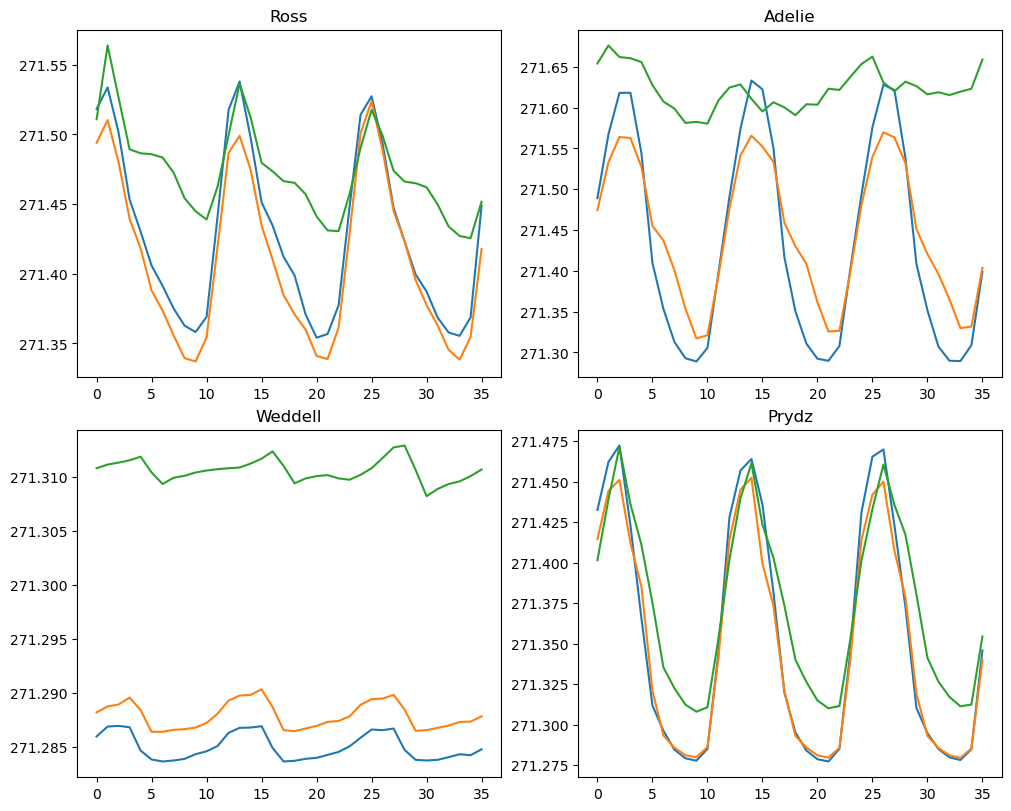

In [85]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), layout="constrained")

ax[0,0].plot(np.nanmean(np.nanmean(temp_ross.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,0].plot(np.nanmean(np.nanmean(temp_ross_ssp.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,0].plot(np.nanmean(np.nanmean(temp_ross_antw.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,0].set_title('Ross')

ax[0,1].plot(np.nanmean(np.nanmean(temp_adelie.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,1].plot(np.nanmean(np.nanmean(temp_adelie_ssp.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,1].plot(np.nanmean(np.nanmean(temp_adelie_antw.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,1].set_title('Adelie')

ax[1,0].plot(np.nanmean(np.nanmean(temp_weddell.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,0].plot(np.nanmean(np.nanmean(temp_weddell_ssp.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,0].plot(np.nanmean(np.nanmean(temp_weddell_antw.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,0].set_title('Weddell')

ax[1,1].plot(np.nanmean(np.nanmean(temp_prydz.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,1].plot(np.nanmean(np.nanmean(temp_prydz_ssp.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,1].plot(np.nanmean(np.nanmean(temp_prydz_antw.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,1].set_title('Prydz')

Text(0.5, 1.0, 'Prydz')

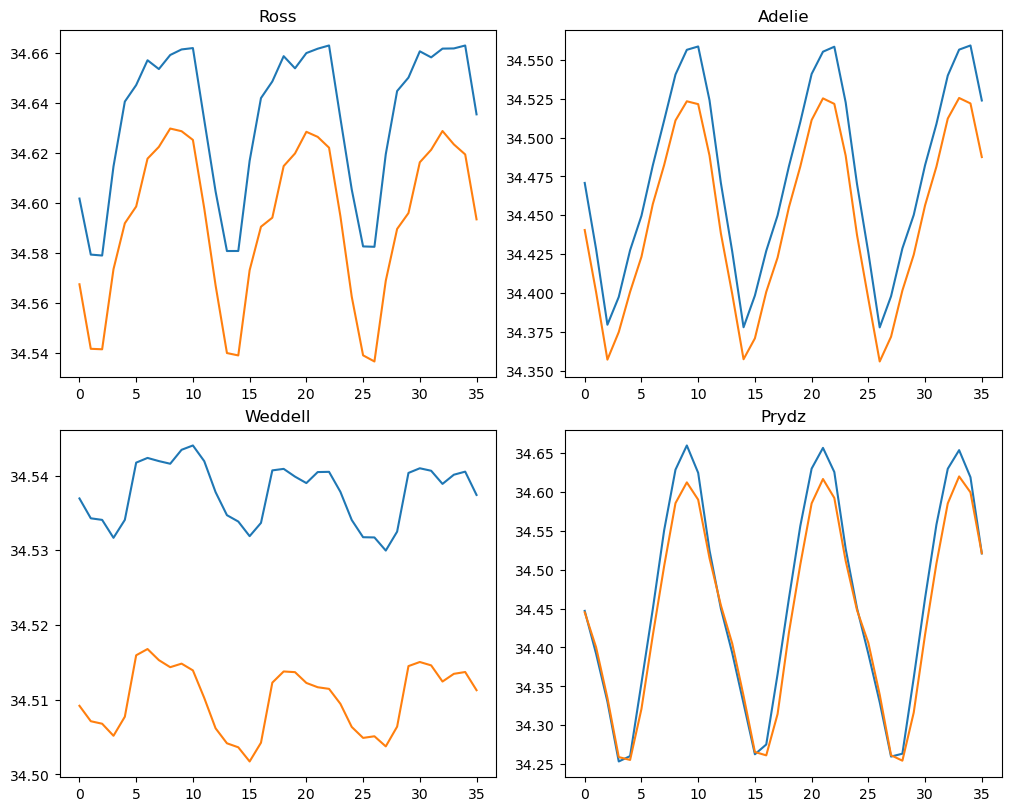

In [36]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), layout="constrained")

ax[0,0].plot(np.nanmean(np.nanmean(salt_ross_basal.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,0].plot(np.nanmean(np.nanmean(salt_ross_basal_ssp.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,0].set_title('Ross')

ax[0,1].plot(np.nanmean(np.nanmean(salt_adelie_basal.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,1].plot(np.nanmean(np.nanmean(salt_adelie_basal_ssp.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,1].set_title('Adelie')

ax[1,0].plot(np.nanmean(np.nanmean(salt_weddell_basal.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,0].plot(np.nanmean(np.nanmean(salt_weddell_basal_ssp.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,0].set_title('Weddell')

ax[1,1].plot(np.nanmean(np.nanmean(salt_prydz_basal.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,1].plot(np.nanmean(np.nanmean(salt_prydz_basal_ssp.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,1].set_title('Prydz')



Text(0.5, 1.0, 'Prydz')

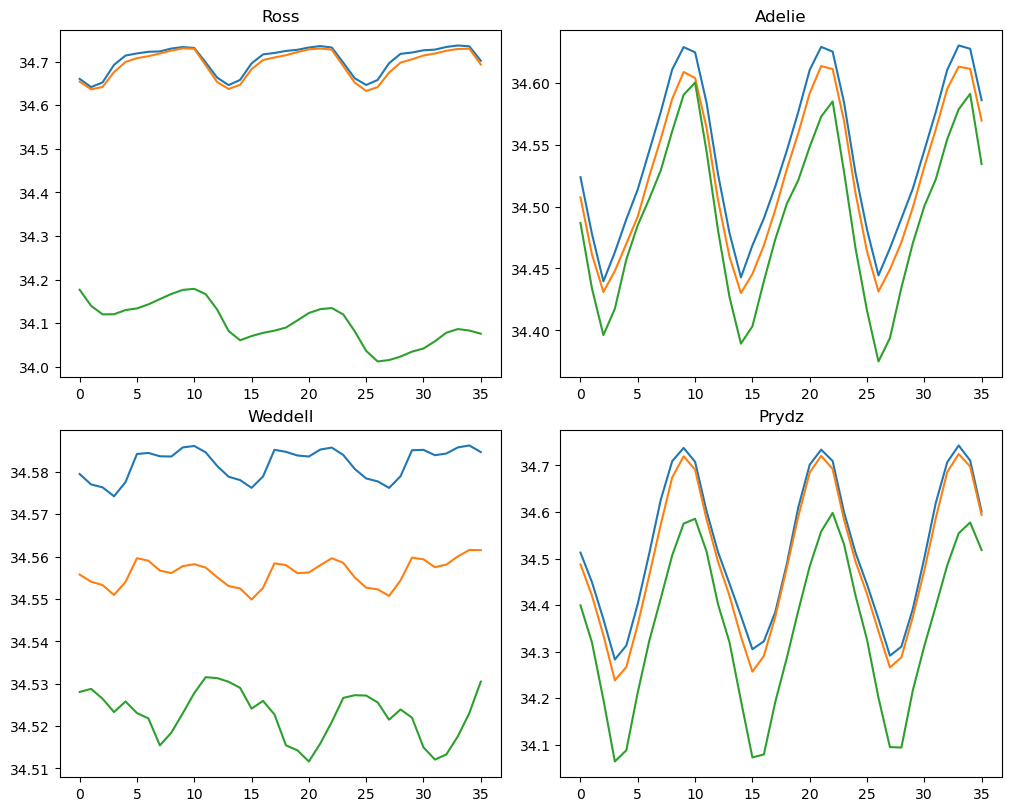

In [37]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), layout="constrained")

ax[0,0].plot(np.nanmean(np.nanmean(salt_ross_basalLH.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,0].plot(np.nanmean(np.nanmean(salt_ross_basalLH_ssp.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,0].plot(np.nanmean(np.nanmean(salt_ross_antw.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,0].set_title('Ross')

ax[0,1].plot(np.nanmean(np.nanmean(salt_adelie_basalLH.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,1].plot(np.nanmean(np.nanmean(salt_adelie_basalLH_ssp.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,1].plot(np.nanmean(np.nanmean(salt_adelie_basalLH_antw.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,1].set_title('Adelie')

ax[1,0].plot(np.nanmean(np.nanmean(salt_weddell_basalLH.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,0].plot(np.nanmean(np.nanmean(salt_weddell_basalLH_ssp.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,0].plot(np.nanmean(np.nanmean(salt_weddell_basalLH_antw.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,0].set_title('Weddell')

ax[1,1].plot(np.nanmean(np.nanmean(salt_prydz_basalLH.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,1].plot(np.nanmean(np.nanmean(salt_prydz_basalLH_ssp.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,1].plot(np.nanmean(np.nanmean(salt_prydz_basalLH_antw.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,1].set_title('Prydz')


Text(0.5, 1.0, 'Prydz')

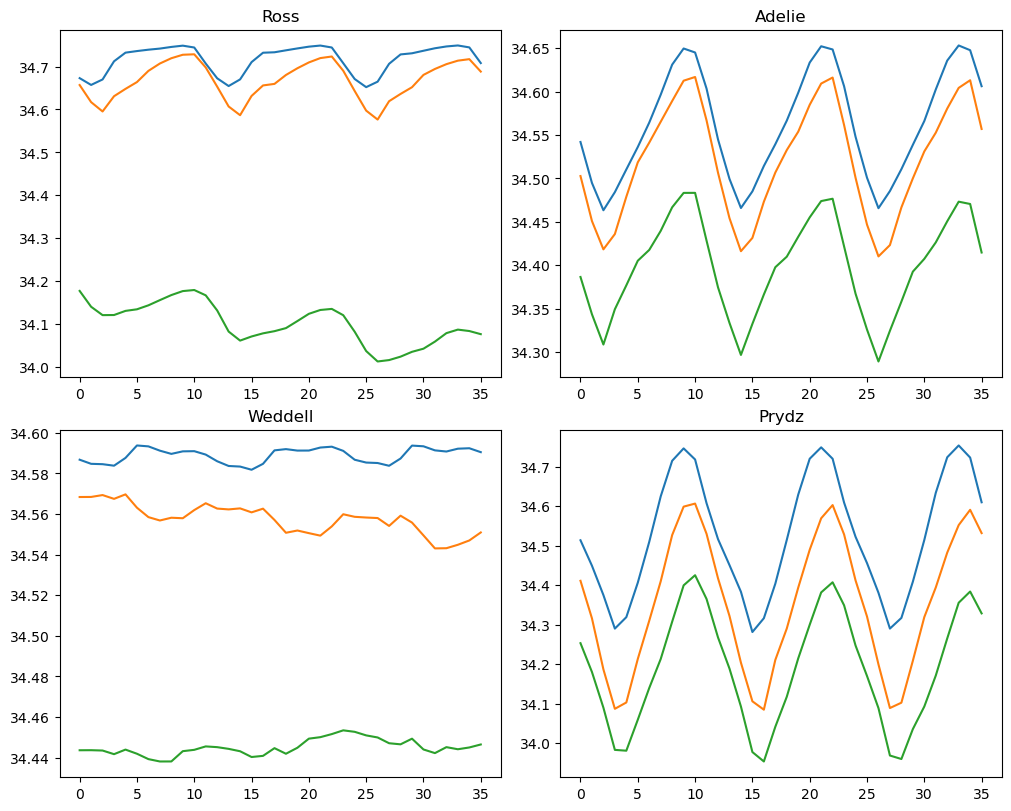

In [38]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), layout="constrained")

ax[0,0].plot(np.nanmean(np.nanmean(salt_ross_LH.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,0].plot(np.nanmean(np.nanmean(salt_ross_LH_antw.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,0].plot(np.nanmean(np.nanmean(salt_ross_antw.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,0].set_title('Ross')

ax[0,1].plot(np.nanmean(np.nanmean(salt_adelie_LH.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,1].plot(np.nanmean(np.nanmean(salt_adelie_LH_antw.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,1].plot(np.nanmean(np.nanmean(salt_adelie_antw_LH.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[0,1].set_title('Adelie')

ax[1,0].plot(np.nanmean(np.nanmean(salt_weddell_LH.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,0].plot(np.nanmean(np.nanmean(salt_weddell_LH_antw.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,0].plot(np.nanmean(np.nanmean(salt_weddell_antw_LH.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,0].set_title('Weddell')

ax[1,1].plot(np.nanmean(np.nanmean(salt_prydz_LH.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,1].plot(np.nanmean(np.nanmean(salt_prydz_LH_antw.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,1].plot(np.nanmean(np.nanmean(salt_prydz_antw_LH.to_dataarray().squeeze(),axis=-1),axis=-1))
ax[1,1].set_title('Prydz')


## Surface heat/FW budget

#### read variables

In [4]:
# budget_dir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/budget_integrated/'
budget_dir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/budget_integrated_winter/'
# budget_dir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/budget_integrated_LargeRegion/'
# budget_dir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/budget_integrated_LargeRegion_winter/'

# print(xr.open_dataset(budget_dir+'river_annual_hint_region_ctrl.nc'))

In [5]:
import os

datasets = {}

for f in glob.glob(budget_dir + '*.nc'):

    key = os.path.basename(f).replace('.nc','')

    datasets[key] = xr.open_dataset(f)

In [6]:
def val(term, exp, region):

    dsname = f'{term}_annual_hint_region_{exp}'

    return datasets[dsname][region].item()


#### testing:

In [7]:
region = 'Ross'

# Runoff
runoff_ctrl = val('HF_runoff','ctrl',region)
runoff_ctrl_a = val('HF_runoff','ctrl_a',region)
runoff_ctrl_a_BG = val('HF_runoff','ctrl_a_BG',region) 
runoff_BGB = val('HF_runoff','BGB',region) 
runoff_BGB_a = val('HF_runoff','BGB_a',region)

# Atmosp. (incl. SI)
coupler_ctrl = val('HF_coupler','ctrl',region) - val('HF_mh','ctrl',region)
coupler_ctrl_a = val('HF_coupler','ctrl_a',region) - val('HF_mh','ctrl_a',region)
coupler_ctrl_a_BG = val('HF_coupler','ctrl_a_BG',region) - val('HF_mh','ctrl_a_BG',region)
coupler_BGB = val('HF_coupler','BGB',region) - val('HF_mh','BGB',region)
coupler_BGB_a = val('HF_coupler','BGB_a',region) - val('HF_mh','BGB_a',region)

# basalmix
# basal_ctrl = val('HF_basalmix','ctrl',region)
# basal_ctrl_a = val('HF_basalmix','ctrl_a',region)
basal_ctrl_a_BG = val('HF_basalmix','ctrl_a_BG',region)
basal_BGB = val('HF_basalmix','BGB',region)
basal_BGB_a = val('HF_basalmix','BGB_a',region)

# PME
pme_ctrl = val('HF_pme','ctrl',region) 
pme_ctrl_a = val('HF_pme','ctrl_a',region)  
pme_ctrl_a_BG = val('HF_pme','ctrl_a_BG',region) 
pme_BGB = val('HF_pme','BGB',region) 
pme_BGB_a = val('HF_pme','BGB_a',region) 

# Frazil
frazil_ctrl = val('HF_frazil','ctrl',region)
frazil_ctrl_a = val('HF_frazil','ctrl_a',region)
frazil_ctrl_a_BG = val('HF_frazil','ctrl_a_BG',region)
frazil_BGB = val('HF_frazil','BGB',region)
frazil_BGB_a = val('HF_frazil','BGB_a',region)

# Sea-ice
mh_ctrl = val('HF_mh','ctrl',region)
mh_ctrl_a = val('HF_mh','ctrl_a',region)
mh_ctrl_a_BG = val('HF_mh','ctrl_a_BG',region)
mh_BGB = val('HF_mh','BGB',region)
mh_BGB_a = val('HF_mh','BGB_a',region)


# NET
net_ctrl = runoff_ctrl + coupler_ctrl + pme_ctrl + frazil_ctrl
net_ctrl_a = runoff_ctrl_a + coupler_ctrl_a + pme_ctrl_a + frazil_ctrl_a
net_ctrl_a_BG = runoff_ctrl_a_BG + coupler_ctrl_a_BG + pme_ctrl_a_BG + frazil_ctrl_a_BG + basal_ctrl_a_BG
net_BGB = runoff_BGB + coupler_BGB + pme_BGB + frazil_BGB + basal_BGB
net_BGB_a = runoff_BGB_a + coupler_BGB_a + pme_BGB_a + frazil_BGB_a + basal_BGB_a


In [62]:
# anomalies

heat_budget = {
    'NET': [
        net_ctrl_a - net_ctrl,
        net_ctrl_a_BG - net_ctrl,
        net_BGB_a - net_BGB,
    ],

    'Runoff + Basal': [
        (runoff_ctrl_a - runoff_ctrl),
        (runoff_ctrl_a_BG+basal_ctrl_a_BG) - runoff_ctrl,
        (runoff_BGB_a+basal_BGB_a) - (runoff_BGB+basal_BGB),
    ],
    
    'Atmosp.': [
        coupler_ctrl_a - coupler_ctrl,
        coupler_ctrl_a_BG - coupler_ctrl,
        coupler_BGB_a - coupler_BGB,
    ],

    'Sea ice': [
        mh_ctrl_a - mh_ctrl,
        mh_ctrl_a_BG - mh_ctrl,
        mh_BGB_a - mh_BGB,
    ],

    'PME': [
        pme_ctrl_a - pme_ctrl,
        pme_ctrl_a_BG - pme_ctrl,
        pme_BGB_a - pme_BGB,
    ],
    
    'Frazil': [
        frazil_ctrl_a - frazil_ctrl,
        frazil_ctrl_a_BG - frazil_ctrl,
        frazil_BGB_a - frazil_BGB,
    ],
}

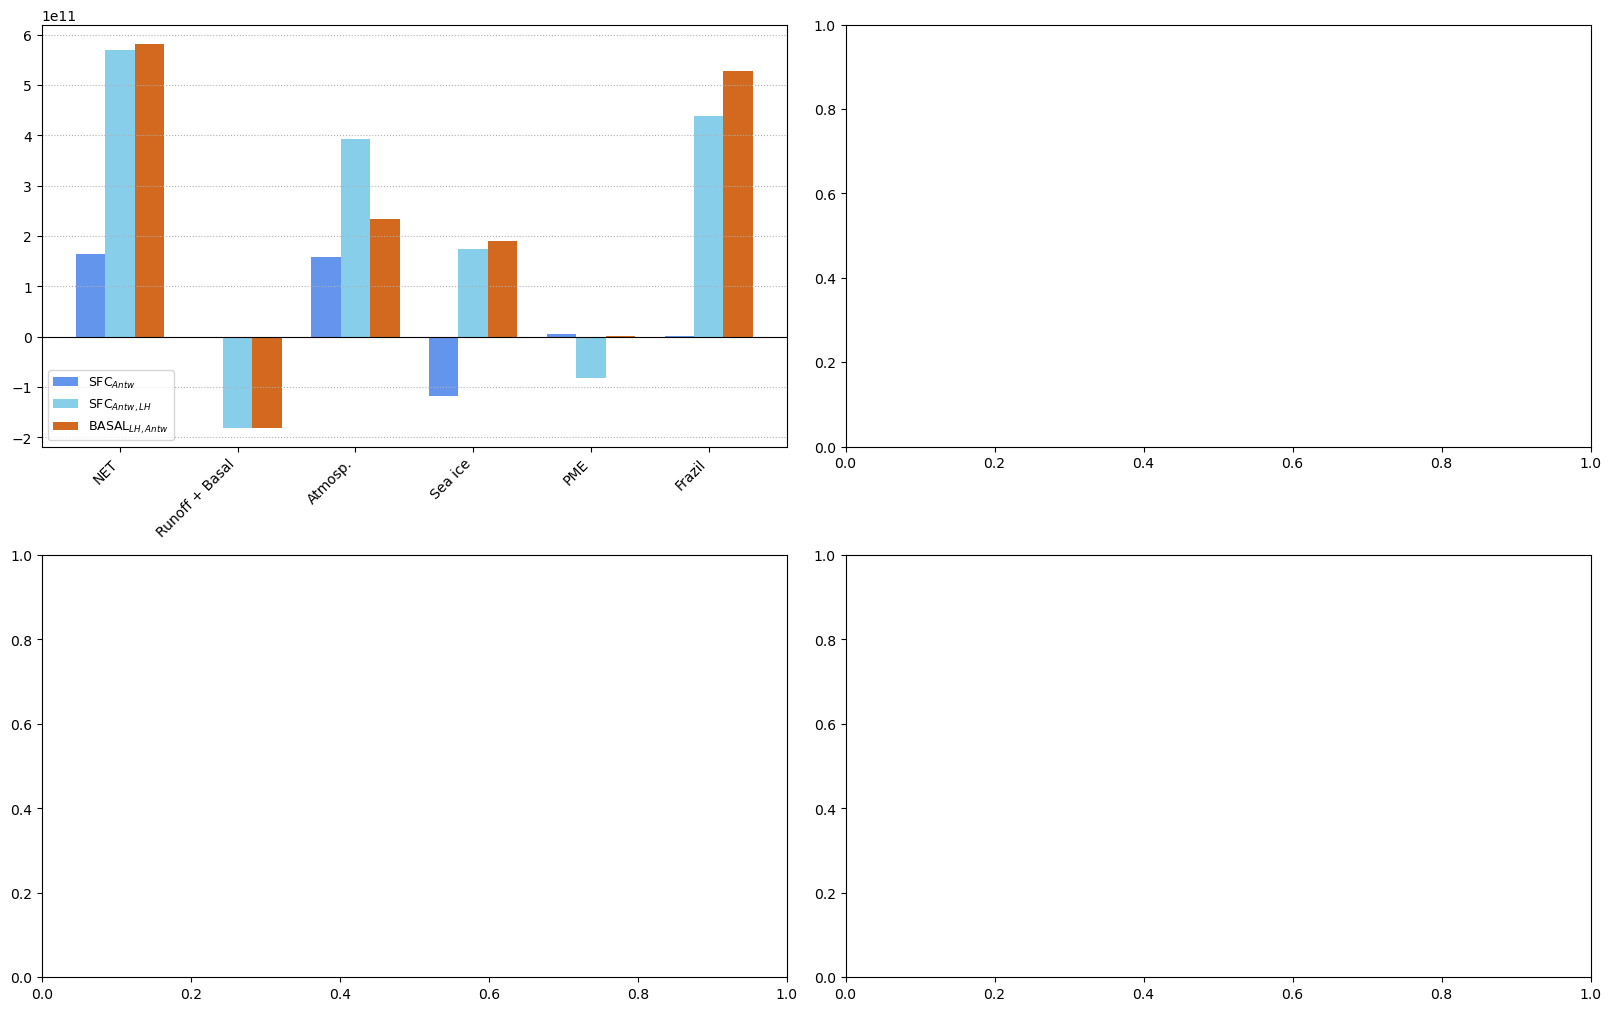

In [63]:
fig, axs = plt.subplots(
    2, 2,
    figsize=(16,10),
    constrained_layout=True
)

ax = axs[0,0]

terms = list(heat_budget.keys())
x = np.arange(len(terms))

width = 0.25

colors = [
    'cornflowerblue',
    'skyblue',
    'chocolate'
]

labels = [
    r'SFC$_{Antw}$',
    r'SFC$_{Antw,LH}$',
    r'BASAL$_{LH,Antw}$'
]

for iexp in range(3):

    vals = [heat_budget[t][iexp] for t in terms]

    ax.bar(
        x + (iexp-1)*width,
        vals,
        width=width,
        color=colors[iexp],
        label=labels[iexp]
    )

ax.axhline(0, color='k', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(
    terms,
    rotation=45,
    ha='right'
)

# ax.set_ylabel(r'Freshwater flux (kg s$^{-1}$)')
# ax.set_title(f'{region}: Freshwater budget anomaly')

ax.grid(True, axis='y', linestyle=':')
ax.legend(fontsize=9)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

#### plots for all regions 

In [7]:
figdir

'/g/data/e14/fbd581/basal_mom5-collaborative-project/'

0
1
2
3


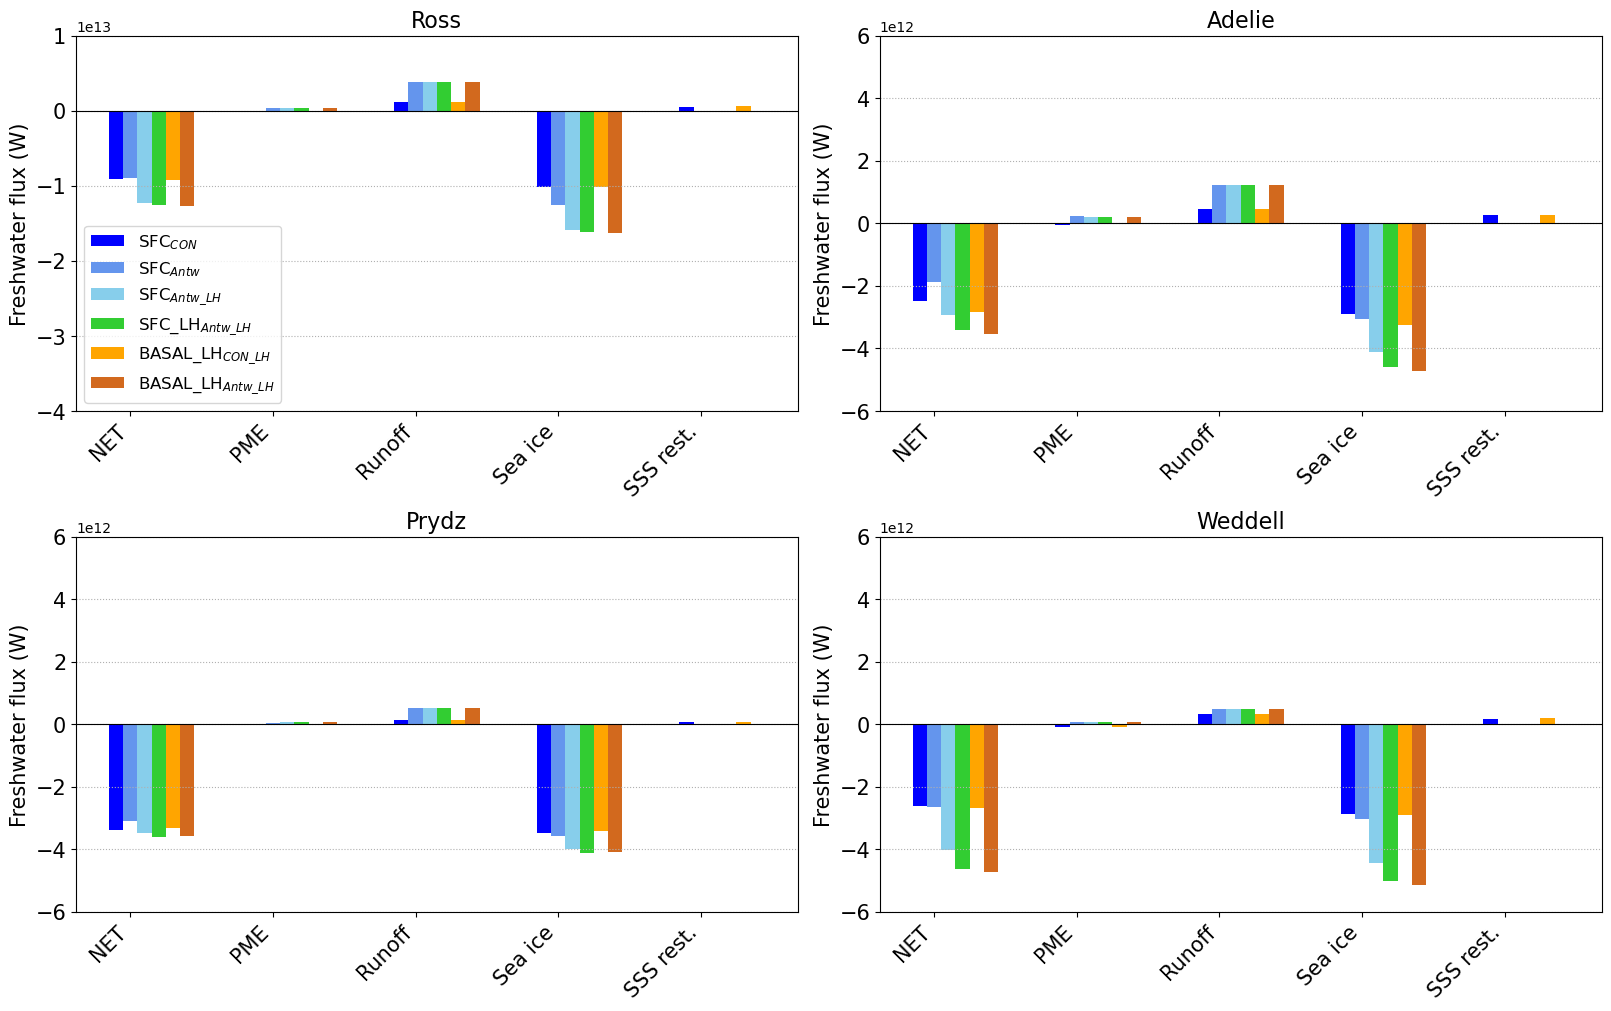

In [8]:
regions = ['Ross','Adelie','Prydz','Weddell']

fig, axs = plt.subplots(
    2, 2,
    figsize=(16,10),
    constrained_layout=True
)

for i, region in enumerate(regions):

    print(i)
    if i == 0:
        ax = axs[0,0]
    elif i == 1:
        ax = axs[0,1]
    elif i == 2:
        ax = axs[1,0]
    elif i == 3:
        ax = axs[1,1]

    #
    # FW budget
    #

    # NET
    net_ctrl = val('pme_river','ctrl',region)
    net_ctrl_a = val('pme_river','ctrl_a',region)
    net_ctrl_a_BG = val('pme_river','ctrl_a_BG',region) + val('basal','ctrl_a_BG',region) + val('brine','ctrl_a_BG',region)
    net_ctrlBG_a = val('pme_river','ctrlBG_a',region) + val('basal','ctrlBG_a',region) + val('brine','ctrlBG_a',region)
    net_BGB = val('pme_river','BGB',region) + val('basal','BGB',region) + val('brine','BGB',region)
    net_BGB_a = val('pme_river','BGB_a',region) + val('basal','BGB_a',region) + val('brine','BGB_a',region)
    
    # PME
    pme_ctrl = val('pme_net','ctrl',region) - (val('wfiform','ctrl',region) + val('wfimelt','ctrl',region))
    pme_ctrl_a = val('pme_net','ctrl_a',region)  - (val('wfiform','ctrl_a',region) + val('wfimelt','ctrl_a',region))
    pme_ctrl_a_BG = val('pme_net','ctrl_a_BG',region) + val('brine','ctrl_a_BG',region) - (val('wfiform','ctrl_a_BG',region) + val('wfimelt','ctrl_a_BG',region))
    pme_ctrlBG_a = val('pme_net','ctrlBG_a',region) + val('brine','ctrlBG_a',region) - (val('wfiform','ctrlBG_a',region) + val('wfimelt','ctrlBG_a',region))
    pme_BGB = val('pme_net','BGB',region) + val('brine','BGB',region)  - (val('wfiform','BGB',region) + val('wfimelt','BGB',region))
    pme_BGB_a = val('pme_net','BGB_a',region) + val('brine','BGB_a',region)  - (val('wfiform','BGB_a',region) + val('wfimelt','BGB_a',region))
    
    # Runoff
    runoff_ctrl = val('river','ctrl',region)
    runoff_ctrl_a = val('river','ctrl_a',region)
    runoff_ctrl_a_BG = val('river','ctrl_a_BG',region) + val('basal','ctrl_a_BG',region)
    runoff_ctrlBG_a = val('river','ctrlBG_a',region) + val('basal','ctrlBG_a',region)
    runoff_BGB = val('river','BGB',region) + val('basal','BGB',region)
    runoff_BGB_a = val('river','BGB_a',region) + val('basal','BGB_a',region)
    
    # Sea ice (net)
    SI_ctrl = (val('wfiform','ctrl',region) + val('wfimelt','ctrl',region))
    SI_ctrl_a = (val('wfiform','ctrl_a',region) + val('wfimelt','ctrl_a',region))
    SI_ctrl_a_BG = (val('wfiform','ctrl_a_BG',region) + val('wfimelt','ctrl_a_BG',region))
    SI_ctrlBG_a = (val('wfiform','ctrlBG_a',region) + val('wfimelt','ctrlBG_a',region))
    SI_BGB = (val('wfiform','BGB',region) + val('wfimelt','BGB',region))
    SI_BGB_a = (val('wfiform','BGB_a',region) + val('wfimelt','BGB_a',region))
    
    # Sea ice (formation)
    SIf_ctrl = (val('wfiform','ctrl',region) )
    SIf_ctrl_a = (val('wfiform','ctrl_a',region) )
    SIf_ctrl_a_BG = (val('wfiform','ctrl_a_BG',region) )
    SIf_ctrlBG_a = (val('wfiform','ctrlBG_a',region) )
    SIf_BGB = (val('wfiform','BGB',region) )
    SIf_BGB_a = (val('wfiform','BGB_a',region) )
    # Sea ice (melting)
    SIm_ctrl = (val('wfimelt','ctrl',region) )
    SIm_ctrl_a = (val('wfimelt','ctrl_a',region) )
    SIm_ctrl_a_BG = (val('wfimelt','ctrl_a_BG',region) )
    SIm_ctrlBG_a = (val('wfimelt','ctrlBG_a',region) )
    SIm_BGB = (val('wfimelt','BGB',region) )
    SIm_BGB_a = (val('wfimelt','BGB_a',region) )
    
    # SSS restoring
    SSSrest_ctrl = val('FW_restore','ctrl',region)
    SSSrest_ctrl_a = val('FW_restore','ctrl_a',region)
    SSSrest_ctrl_a_BG = val('FW_restore','ctrl_a_BG',region)
    SSSrest_ctrlBG_a = val('FW_restore','ctrlBG_a',region)
    SSSrest_BGB = val('FW_restore','BGB',region)
    SSSrest_BGB_a = val('FW_restore','BGB_a',region)

    # FW from ice
    Ice_ctrl = val('FW_ice','ctrl',region)
    Ice_ctrl_a = val('FW_ice','ctrl_a',region)
    Ice_ctrl_a_BG = val('FW_ice','ctrl_a_BG',region)
    Ice_ctrlBG_a = val('FW_ice','ctrlBG_a',region)
    Ice_BGB = val('FW_ice','BGB',region)
    Ice_BGB_a = val('FW_ice','BGB_a',region)

    # anomalies
    fw_budget = {
    'NET': [
        net_ctrl,
        net_ctrl_a,# - net_ctrl,
        net_ctrl_a_BG,# - net_ctrl,
        net_ctrlBG_a,# - net_ctrl,
        net_BGB,
        net_BGB_a,# - net_BGB,
    ],

    'PME': [
        pme_ctrl,
        pme_ctrl_a,# - pme_ctrl,
        pme_ctrl_a_BG,# - pme_ctrl,
        pme_ctrlBG_a,# - pme_ctrl,
        pme_BGB,
        pme_BGB_a,# - pme_BGB,
    ],

    'Runoff': [
        runoff_ctrl,
        runoff_ctrl_a,# - runoff_ctrl,
        runoff_ctrl_a_BG,# - runoff_ctrl,
        runoff_ctrlBG_a,# - runoff_ctrl,
        runoff_BGB,
        runoff_BGB_a,# - runoff_BGB,
    ],

    'Sea ice': [
        SI_ctrl,
        SI_ctrl_a,# - SI_ctrl,
        SI_ctrl_a_BG,# - SI_ctrl,
        SI_ctrlBG_a,# - SI_ctrl,
        SI_BGB,
        SI_BGB_a,# - SI_BGB,
    ],

    # 'Sea ice form.': [
    #     SIf_ctrl,
    #     SIf_ctrl_a,# - SIf_ctrl,
    #     SIf_ctrl_a_BG,# - SIf_ctrl,
    #     SIf_ctrlBG_a,# - SIf_ctrl,
    #     SIf_BGB,
    #     SIf_BGB_a,# - SIf_BGB,
    # ],

    # 'Sea ice melt.': [
    #     SIm_ctrl,
    #     SIm_ctrl_a,# - SIm_ctrl,
    #     SIm_ctrl_a_BG,# - SIm_ctrl,
    #     SIm_ctrlBG_a,# - SIm_ctrl,
    #     SIm_BGB,
    #     SIm_BGB_a,# - SIm_BGB,
    # ],

    'SSS rest.': [
        SSSrest_ctrl,
        SSSrest_ctrl_a,# - SSSrest_ctrl,
        SSSrest_ctrl_a_BG,# - SSSrest_ctrl,
        SSSrest_ctrlBG_a,# - SSSrest_ctrl,
        SSSrest_BGB,
        SSSrest_BGB_a,# - SSSrest_BGB,
    ],

    # 'Ice': [
    #     Ice_ctrl_a - SSSrest_ctrl,
    #     Ice_ctrl_a_BG - SSSrest_ctrl,
    #     Ice_BGB_a - SSSrest_BGB,
    # ],
    }

    terms = list(fw_budget.keys())
    x = np.arange(len(terms))
    
    width = 0.1
    
    colors = [
        'blue',
        'cornflowerblue',
        'skyblue',
        'limegreen',
        'orange',
        'chocolate'
    ]
    
    labels = [
        r'SFC$_{CON}$',
        r'SFC$_{Antw}$',
        r'SFC$_{Antw\_LH}$',
        r'SFC_LH$_{Antw\_LH}$',
        r'BASAL_LH$_{CON\_LH}$',
        r'BASAL_LH$_{Antw\_LH}$'
    ]
    
    for iexp in range(6):
    
        vals = [fw_budget[t][iexp]* 3.34e5 for t in terms]

        ax.bar(
            x + (iexp-1)*width,
            (vals), ### MULTIPLYING BY LATENT HEAT OF VAPORISATION TO CONVERT FWF TO HEAT FLUX UNITS!
            width=width,
            color=colors[iexp],
            label=labels[iexp]
        )
    
    ax.axhline(0, color='k', linewidth=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(
        terms,
        rotation=45,
        ha='right',
        fontsize=15
    )
    
    # ax.set_ylabel(r'Freshwater flux (kg s$^{-1}$)',fontsize=15)
    ax.set_ylabel(r'Freshwater flux (W)',fontsize=15)
    
    
    # ax.set_title(f'{region}: Freshwater budget',fontsize=16)
    ax.set_title(f'{region}',fontsize=16)
    
    ax.grid(True, axis='y', linestyle=':')
    if region == 'Ross':
        ax.legend(fontsize=12)
        ax.set_ylim(-40e12,10e12) ## for W units
    else:
        ax.set_ylim(-6e12,6e12) ## for W units
    ax.tick_params(labelsize=15)
    # ax.set_ylim(-2.5e7,1.5e7)
    # ax.set_ylim(-40e12,10e12) ## for W units

    # ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

    #
    # Heat budget
    #

    # hf_runoff = val('HF_runoff','ctrl',region)

    # ax_hf.bar(...)

    # ax_hf.set_title(region)

## Save fig
plt.savefig(figdir+'FWBudget_annual_shelf_yr17-20_DSWregions_abs_winter.png',bbox_inches='tight',dpi=300)
# plt.savefig(figdir+'FWBudget_annual_shelf_yr17-20_DSWregions_abs_LargeRegion_winter.png',bbox_inches='tight',dpi=300)
# plt.savefig(figdir+'FWBudget_annual_shelf_yr17-20_DSWregions_anom.png',bbox_inches='tight',dpi=300)
plt.show()


0
1
2
3


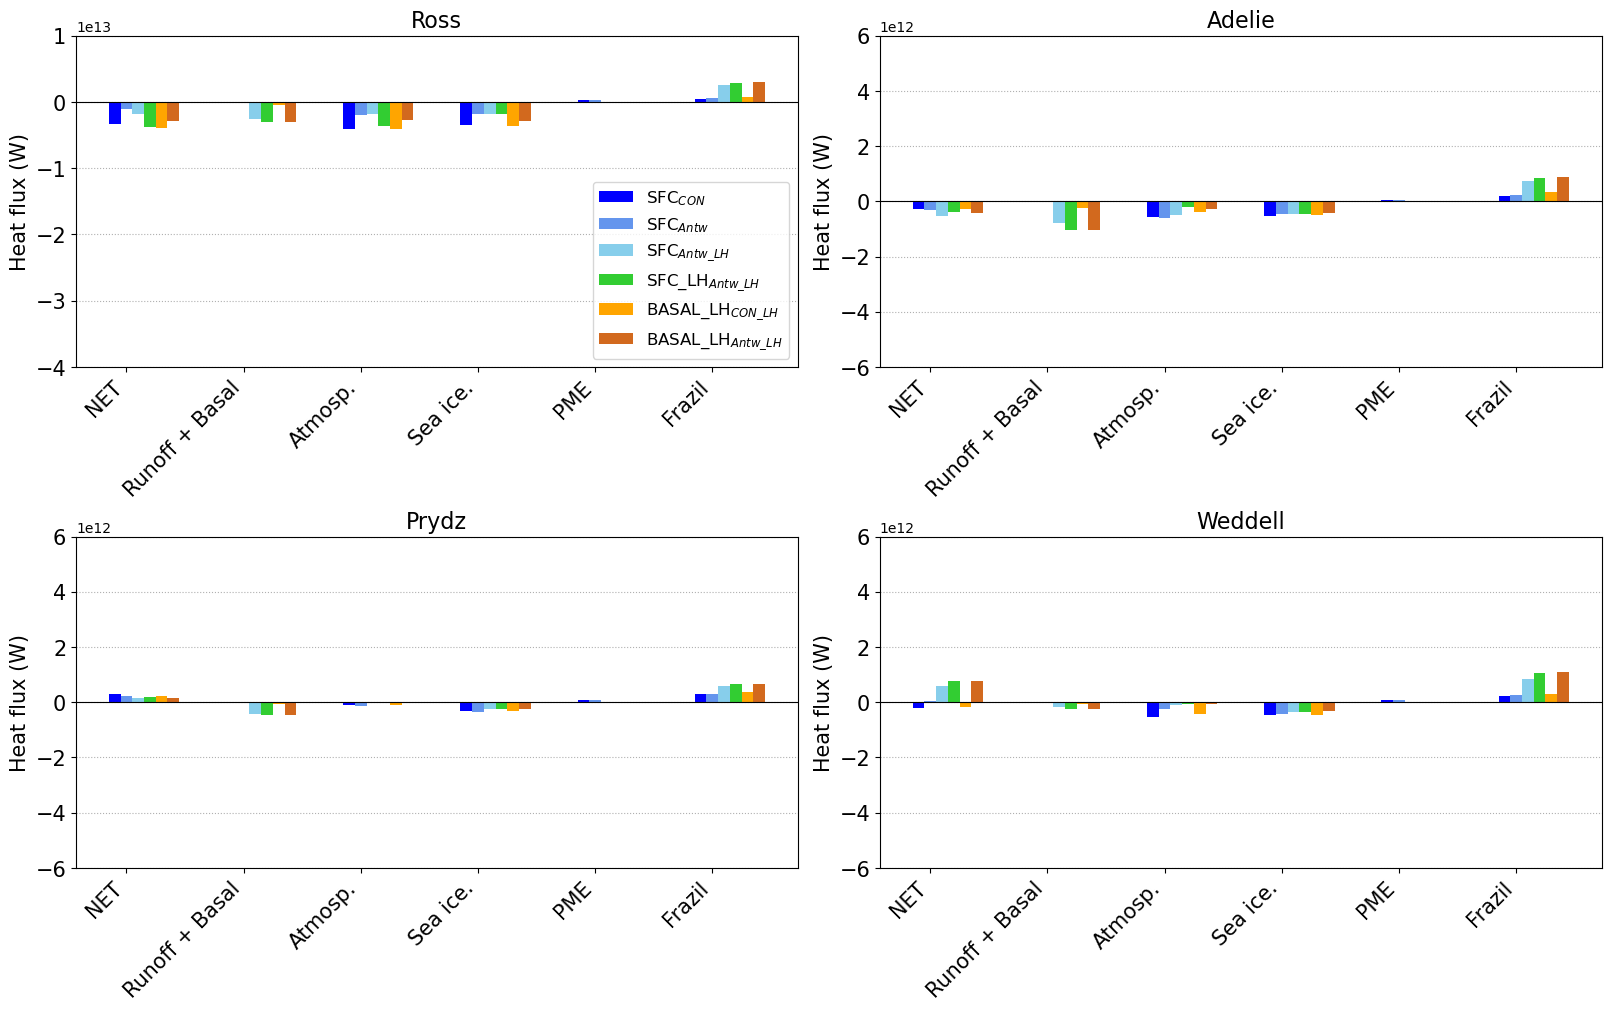

In [9]:
regions = ['Ross','Adelie','Prydz','Weddell']

fig, axs = plt.subplots(
    2, 2,
    figsize=(16,10),
    constrained_layout=True
)

for i, region in enumerate(regions):

    print(i)
    if i == 0:
        ax = axs[0,0]
    elif i == 1:
        ax = axs[0,1]
    elif i == 2:
        ax = axs[1,0]
    elif i == 3:
        ax = axs[1,1]

    #
    # Heat budget
    #

    # Runoff
    runoff_ctrl = val('HF_runoff','ctrl',region)
    runoff_ctrl_a = val('HF_runoff','ctrl_a',region)
    runoff_ctrl_a_BG = val('HF_runoff','ctrl_a_BG',region) 
    runoff_ctrlBG_a = val('HF_runoff','ctrlBG_a',region) 
    runoff_BGB = val('HF_runoff','BGB',region) 
    runoff_BGB_a = val('HF_runoff','BGB_a',region)
    
    # Atmosp. (incl. SI)
    coupler_ctrl = val('HF_coupler','ctrl',region) - val('HF_mh','ctrl',region)
    coupler_ctrl_a = val('HF_coupler','ctrl_a',region) - val('HF_mh','ctrl_a',region)
    coupler_ctrl_a_BG = val('HF_coupler','ctrl_a_BG',region) - val('HF_mh','ctrl_a_BG',region)
    coupler_ctrlBG_a = val('HF_coupler','ctrlBG_a',region) - val('HF_mh','ctrlBG_a',region)
    coupler_BGB = val('HF_coupler','BGB',region) - val('HF_mh','BGB',region)
    coupler_BGB_a = val('HF_coupler','BGB_a',region) - val('HF_mh','BGB_a',region)
    
    # basalmix
    # basal_ctrl = val('HF_basalmix','ctrl',region)
    # basal_ctrl_a = val('HF_basalmix','ctrl_a',region)
    basal_ctrl_a_BG = val('HF_basalmix','ctrl_a_BG',region)
    basal_ctrlBG_a = val('HF_basalmix','ctrlBG_a',region)
    basal_BGB = val('HF_basalmix','BGB',region)
    basal_BGB_a = val('HF_basalmix','BGB_a',region)
    
    # PME
    pme_ctrl = val('HF_pme','ctrl',region) 
    pme_ctrl_a = val('HF_pme','ctrl_a',region)  
    pme_ctrl_a_BG = val('HF_pme','ctrl_a_BG',region) 
    pme_ctrlBG_a = val('HF_pme','ctrlBG_a',region) 
    pme_BGB = val('HF_pme','BGB',region) 
    pme_BGB_a = val('HF_pme','BGB_a',region) 
    
    # Frazil
    frazil_ctrl = val('HF_frazil','ctrl',region)
    frazil_ctrl_a = val('HF_frazil','ctrl_a',region)
    frazil_ctrl_a_BG = val('HF_frazil','ctrl_a_BG',region)
    frazil_ctrlBG_a = val('HF_frazil','ctrlBG_a',region)
    frazil_BGB = val('HF_frazil','BGB',region)
    frazil_BGB_a = val('HF_frazil','BGB_a',region)
    
    # Sea-ice
    mh_ctrl = val('HF_mh','ctrl',region)
    mh_ctrl_a = val('HF_mh','ctrl_a',region)
    mh_ctrl_a_BG = val('HF_mh','ctrl_a_BG',region)
    mh_ctrlBG_a = val('HF_mh','ctrlBG_a',region)
    mh_BGB = val('HF_mh','BGB',region)
    mh_BGB_a = val('HF_mh','BGB_a',region)
    
    
    # NET
    net_ctrl = runoff_ctrl + coupler_ctrl + pme_ctrl + frazil_ctrl
    net_ctrl_a = runoff_ctrl_a + coupler_ctrl_a + pme_ctrl_a + frazil_ctrl_a
    net_ctrl_a_BG = runoff_ctrl_a_BG + coupler_ctrl_a_BG + pme_ctrl_a_BG + frazil_ctrl_a_BG + basal_ctrl_a_BG
    net_ctrlBG_a = runoff_ctrlBG_a + coupler_ctrlBG_a + pme_ctrlBG_a + frazil_ctrlBG_a + basal_ctrlBG_a
    net_BGB = runoff_BGB + coupler_BGB + pme_BGB + frazil_BGB + basal_BGB
    net_BGB_a = runoff_BGB_a + coupler_BGB_a + pme_BGB_a + frazil_BGB_a + basal_BGB_a

    # anomalies

    heat_budget = {
    'NET': [
        net_ctrl,
        net_ctrl_a,# - net_ctrl,
        net_ctrl_a_BG,# - net_ctrl,
        net_ctrlBG_a,# - net_ctrl,
        net_BGB,
        net_BGB_a,# - net_BGB,
    ],

    'Runoff + Basal': [
        (runoff_ctrl),
        (runoff_ctrl_a),# - runoff_ctrl,
        (runoff_ctrl_a_BG+basal_ctrl_a_BG),# - runoff_ctrl,
        (runoff_ctrlBG_a+basal_ctrlBG_a),# - runoff_ctrl,
        (runoff_BGB+basal_BGB),
        (runoff_BGB_a+basal_BGB_a),# - (runoff_BGB+basal_BGB),
    ],
    
    'Atmosp.': [
        (coupler_ctrl ),
        (coupler_ctrl_a),# - coupler_ctrl,
        (coupler_ctrl_a_BG),# - coupler_ctrl,
        (coupler_ctrlBG_a),# - coupler_ctrl,
        (coupler_BGB ),
        (coupler_BGB_a),# - coupler_BGB,
    ],

    'Sea ice.': [
        mh_ctrl,
        mh_ctrl_a,# - mh_ctrl,
        mh_ctrl_a_BG,# - mh_ctrl,
        mh_ctrlBG_a,# - mh_ctrl,
        mh_BGB,
        mh_BGB_a,# - mh_BGB,
    ],

    'PME': [
        pme_ctrl,
        pme_ctrl_a,# - pme_ctrl,
        pme_ctrl_a_BG,# - pme_ctrl,
        pme_ctrlBG_a,# - pme_ctrl,
        pme_BGB,
        pme_BGB_a,# - pme_BGB,
    ],
    

    'Frazil': [
        frazil_ctrl,
        frazil_ctrl_a,# - frazil_ctrl,
        frazil_ctrl_a_BG,# - frazil_ctrl,
        frazil_ctrlBG_a,# - frazil_ctrl,
        frazil_BGB,
        frazil_BGB_a,# - frazil_BGB,
    ],
}

    terms = list(heat_budget.keys())
    x = np.arange(len(terms))
    
    width = 0.1
    
    colors = [
        'blue',
        'cornflowerblue',
        'skyblue',
        'limegreen',
        'orange',
        'chocolate'
    ]
    
    labels = [
        r'SFC$_{CON}$',
        r'SFC$_{Antw}$',
        r'SFC$_{Antw\_LH}$',
        r'SFC_LH$_{Antw\_LH}$',
        r'BASAL_LH$_{CON\_LH}$',
        r'BASAL_LH$_{Antw\_LH}$'
    ]
    
    for iexp in range(6):
    
        vals = [heat_budget[t][iexp] for t in terms]
    
        ax.bar(
            x + (iexp-1)*width,
            vals,
            width=width,
            color=colors[iexp],
            label=labels[iexp]
        )
    
    ax.axhline(0, color='k', linewidth=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(
        terms,
        rotation=45,
        ha='right',
        fontsize=15
    )
    
    ax.set_ylabel(r'Heat flux (W)', fontsize=15)
    # ax.set_title(f'{region}: Heat budget ')
    ax.set_title(f'{region}',fontsize=16)
    
    ax.grid(True, axis='y', linestyle=':')
    if region == 'Ross':
        ax.legend(loc='lower right',fontsize=12)
        ax.set_ylim(-40e12,10e12) ## for W units
    else:
        ax.set_ylim(-6e12,6e12) ## for W units
    ax.tick_params(labelsize=15)
    # ax.set_ylim(-6.e12,3.e12)
    # ax.set_ylim(-40e12,10e12) ## for W units

## Save fig
plt.savefig(figdir+'HeatBudget_annual_shelf_yr17-20_DSWregions_abs_winter.png',bbox_inches='tight',dpi=300)
# plt.savefig(figdir+'HeatBudget_annual_shelf_yr17-20_DSWregions_abs_LargeRegion_winter.png',bbox_inches='tight',dpi=300)
# plt.savefig(figdir+'HeatBudget_annual_shelf_yr17-20_DSWregions_anom.png',bbox_inches='tight',dpi=300)
plt.show()

### X-Y plots with 'Bottom salinity anomaly' x 'MW anomaly'

In [86]:
MW_values = [0.08808386, 0.08808386+0.015, 0.08808386+0.1]

In [87]:
np.nanmean(np.nanmean(salt_ross.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)

np.float32(34.651794)

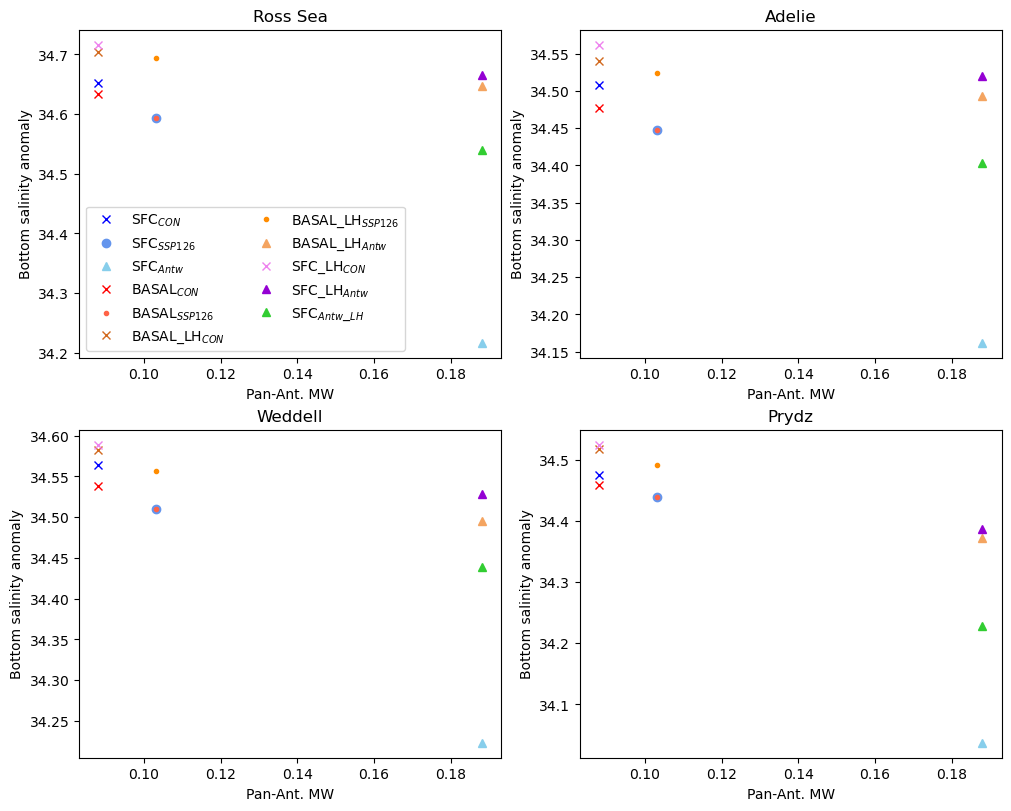

In [88]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), layout="constrained")

ax[0,0].plot(MW_values[0], np.nanmean(np.nanmean(salt_ross.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='blue',label=r'SFC$_{CON}$')
ax[0,0].plot(MW_values[1], np.nanmean(np.nanmean(salt_ross_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'o',color='cornflowerblue',label=r'SFC$_{SSP126}$')
ax[0,0].plot(MW_values[2], np.nanmean(np.nanmean(salt_ross_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='skyblue',label=r'SFC$_{Antw}$')

ax[0,0].plot(MW_values[0], np.nanmean(np.nanmean(salt_ross_basal.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='r',label=r'BASAL$_{CON}$')
ax[0,0].plot(MW_values[1], np.nanmean(np.nanmean(salt_ross_basal_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='tomato',label=r'BASAL$_{SSP126}$')

ax[0,0].plot(MW_values[0], np.nanmean(np.nanmean(salt_ross_basalLH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='chocolate',label=r'BASAL_LH$_{CON}$')
ax[0,0].plot(MW_values[1], np.nanmean(np.nanmean(salt_ross_basalLH_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='darkorange',label=r'BASAL_LH$_{SSP126}$')
ax[0,0].plot(MW_values[2], np.nanmean(np.nanmean(salt_ross_basalLH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='sandybrown',label=r'BASAL_LH$_{Antw}$')

ax[0,0].plot(MW_values[0], np.nanmean(np.nanmean(salt_ross_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='violet',label=r'SFC_LH$_{CON}$')
ax[0,0].plot(MW_values[2], np.nanmean(np.nanmean(salt_ross_LH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='darkviolet',label=r'SFC_LH$_{Antw}$')
ax[0,0].plot(MW_values[2], np.nanmean(np.nanmean(salt_ross_antw_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='limegreen',label=r'SFC$_{Antw}$_$_{LH}$')

ax[0,0].legend(ncol=2)
ax[0,0].set_ylabel('Bottom salinity anomaly')
ax[0,0].set_xlabel('Pan-Ant. MW')
ax[0,0].set_title('Ross Sea')

ax[0,1].plot(MW_values[0], np.nanmean(np.nanmean(salt_adelie.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='blue',label=r'SFC$_{CON}$')
ax[0,1].plot(MW_values[1], np.nanmean(np.nanmean(salt_adelie_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'o',color='cornflowerblue',label=r'SFC$_{SSP126}$')
ax[0,1].plot(MW_values[2], np.nanmean(np.nanmean(salt_adelie_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='skyblue',label=r'SFC$_{Antw}$')

ax[0,1].plot(MW_values[0], np.nanmean(np.nanmean(salt_adelie_basal.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='r',label=r'BASAL$_{CON}$')
ax[0,1].plot(MW_values[1], np.nanmean(np.nanmean(salt_adelie_basal_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='tomato',label=r'BASAL$_{SSP126}$')

ax[0,1].plot(MW_values[0], np.nanmean(np.nanmean(salt_adelie_basalLH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='chocolate',label=r'BASAL_LH$_{CON}$')
ax[0,1].plot(MW_values[1], np.nanmean(np.nanmean(salt_adelie_basalLH_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='darkorange',label=r'BASAL_LH$_{SSP126}$')
ax[0,1].plot(MW_values[2], np.nanmean(np.nanmean(salt_adelie_basalLH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='sandybrown',label=r'BASAL_LH$_{Antw}$')

ax[0,1].plot(MW_values[0], np.nanmean(np.nanmean(salt_adelie_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='violet',label=r'SFC_LH$_{CON}$')
ax[0,1].plot(MW_values[2], np.nanmean(np.nanmean(salt_adelie_LH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='darkviolet',label=r'SFC_LH$_{Antw}$')
ax[0,1].plot(MW_values[2], np.nanmean(np.nanmean(salt_adelie_antw_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='limegreen',label=r'SFC$_{Antw}$_$_{LH}$')

# ax[0,1].legend(ncol=2)
ax[0,1].set_ylabel('Bottom salinity anomaly')
ax[0,1].set_xlabel('Pan-Ant. MW')
ax[0,1].set_title('Adelie')

ax[1,0].plot(MW_values[0], np.nanmean(np.nanmean(salt_weddell.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='blue',label=r'SFC$_{CON}$')
ax[1,0].plot(MW_values[1], np.nanmean(np.nanmean(salt_weddell_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'o',color='cornflowerblue',label=r'SFC$_{SSP126}$')
ax[1,0].plot(MW_values[2], np.nanmean(np.nanmean(salt_weddell_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='skyblue',label=r'SFC$_{Antw}$')

ax[1,0].plot(MW_values[0], np.nanmean(np.nanmean(salt_weddell_basal.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='r',label=r'BASAL$_{CON}$')
ax[1,0].plot(MW_values[1], np.nanmean(np.nanmean(salt_weddell_basal_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='tomato',label=r'BASAL$_{SSP126}$')

ax[1,0].plot(MW_values[0], np.nanmean(np.nanmean(salt_weddell_basalLH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='chocolate',label=r'BASAL_LH$_{CON}$')
ax[1,0].plot(MW_values[1], np.nanmean(np.nanmean(salt_weddell_basalLH_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='darkorange',label=r'BASAL_LH$_{SSP126}$')
ax[1,0].plot(MW_values[2], np.nanmean(np.nanmean(salt_weddell_basalLH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='sandybrown',label=r'BASAL_LH$_{Antw}$')

ax[1,0].plot(MW_values[0], np.nanmean(np.nanmean(salt_weddell_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='violet',label=r'SFC_LH$_{CON}$')
ax[1,0].plot(MW_values[2], np.nanmean(np.nanmean(salt_weddell_LH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='darkviolet',label=r'SFC_LH$_{Antw}$')
ax[1,0].plot(MW_values[2], np.nanmean(np.nanmean(salt_weddell_antw_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='limegreen',label=r'SFC$_{Antw}$_$_{LH}$')

# ax[1,0].legend(ncol=2)
ax[1,0].set_ylabel('Bottom salinity anomaly')
ax[1,0].set_xlabel('Pan-Ant. MW')
ax[1,0].set_title('Weddell')

ax[1,1].plot(MW_values[0], np.nanmean(np.nanmean(salt_prydz.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='blue',label=r'SFC$_{CON}$')
ax[1,1].plot(MW_values[1], np.nanmean(np.nanmean(salt_prydz_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'o',color='cornflowerblue',label=r'SFC$_{SSP126}$')
ax[1,1].plot(MW_values[2], np.nanmean(np.nanmean(salt_prydz_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='skyblue',label=r'SFC$_{Antw}$')

ax[1,1].plot(MW_values[0], np.nanmean(np.nanmean(salt_prydz_basal.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='r',label=r'BASAL$_{CON}$')
ax[1,1].plot(MW_values[1], np.nanmean(np.nanmean(salt_prydz_basal_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='tomato',label=r'BASAL$_{SSP126}$')

ax[1,1].plot(MW_values[0], np.nanmean(np.nanmean(salt_prydz_basalLH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='chocolate',label=r'BASAL_LH$_{CON}$')
ax[1,1].plot(MW_values[1], np.nanmean(np.nanmean(salt_prydz_basalLH_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='darkorange',label=r'BASAL_LH$_{SSP126}$')
ax[1,1].plot(MW_values[2], np.nanmean(np.nanmean(salt_prydz_basalLH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='sandybrown',label=r'BASAL_LH$_{Antw}$')

ax[1,1].plot(MW_values[0], np.nanmean(np.nanmean(salt_prydz_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='violet',label=r'SFC_LH$_{CON}$')
ax[1,1].plot(MW_values[2], np.nanmean(np.nanmean(salt_prydz_LH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='darkviolet',label=r'SFC_LH$_{Antw}$')
ax[1,1].plot(MW_values[2], np.nanmean(np.nanmean(salt_prydz_antw_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='limegreen',label=r'SFC$_{Antw}$_$_{LH}$')

# ax[1,1].legend(ncol=2)
ax[1,1].set_ylabel('Bottom salinity anomaly')
ax[1,1].set_xlabel('Pan-Ant. MW')
ax[1,1].set_title('Prydz')

plt.savefig(figdir+'Relation_MWinputXbottom_salt.png',bbox_inches='tight',dpi=300)
plt.show()

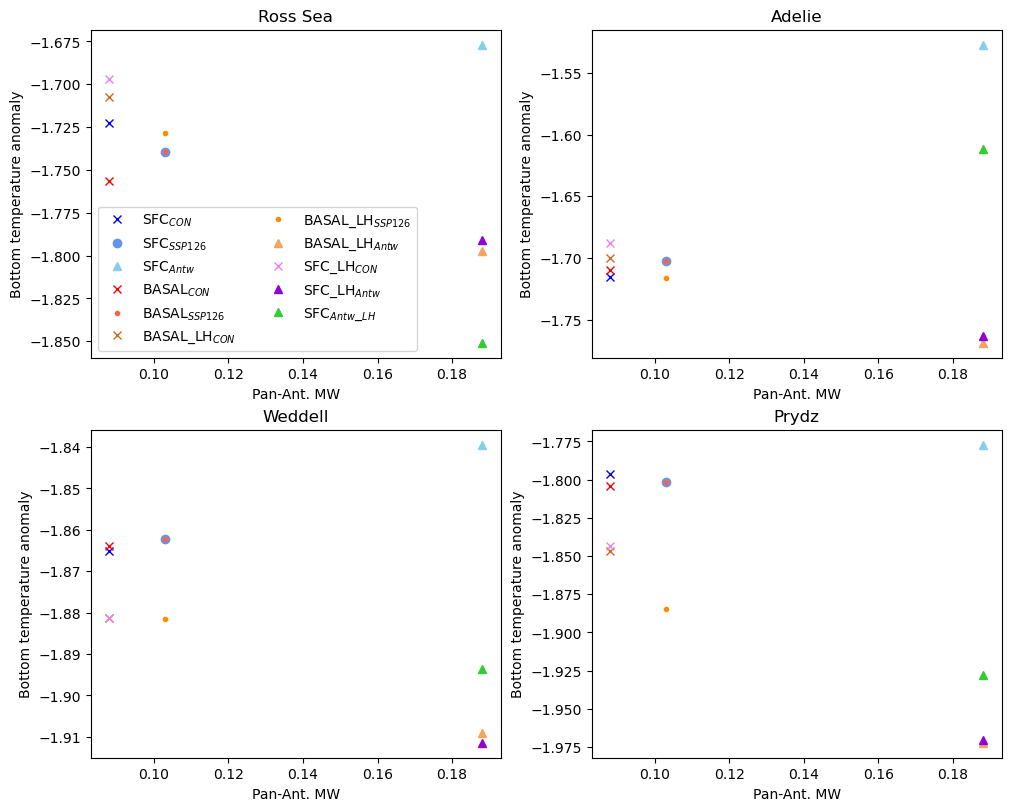

In [89]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), layout="constrained")

ax[0,0].plot(MW_values[0], np.nanmean(np.nanmean(temp_ross.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='blue',label=r'SFC$_{CON}$')
ax[0,0].plot(MW_values[1], np.nanmean(np.nanmean(temp_ross_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'o',color='cornflowerblue',label=r'SFC$_{SSP126}$')
ax[0,0].plot(MW_values[2], np.nanmean(np.nanmean(temp_ross_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='skyblue',label=r'SFC$_{Antw}$')

ax[0,0].plot(MW_values[0], np.nanmean(np.nanmean(temp_ross_basal.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='r',label=r'BASAL$_{CON}$')
ax[0,0].plot(MW_values[1], np.nanmean(np.nanmean(temp_ross_basal_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '.',color='tomato',label=r'BASAL$_{SSP126}$')

ax[0,0].plot(MW_values[0], np.nanmean(np.nanmean(temp_ross_basalLH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='chocolate',label=r'BASAL_LH$_{CON}$')
ax[0,0].plot(MW_values[1], np.nanmean(np.nanmean(temp_ross_basalLH_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '.',color='darkorange',label=r'BASAL_LH$_{SSP126}$')
ax[0,0].plot(MW_values[2], np.nanmean(np.nanmean(temp_ross_basalLH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='sandybrown',label=r'BASAL_LH$_{Antw}$')

ax[0,0].plot(MW_values[0], np.nanmean(np.nanmean(temp_ross_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='violet',label=r'SFC_LH$_{CON}$')
ax[0,0].plot(MW_values[2], np.nanmean(np.nanmean(temp_ross_LH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='darkviolet',label=r'SFC_LH$_{Antw}$')
ax[0,0].plot(MW_values[2], np.nanmean(np.nanmean(temp_ross_antw_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='limegreen',label=r'SFC$_{Antw}$_$_{LH}$')

ax[0,0].legend(ncol=2)
ax[0,0].set_ylabel('Bottom temperature anomaly')
ax[0,0].set_xlabel('Pan-Ant. MW')
ax[0,0].set_title('Ross Sea')

ax[0,1].plot(MW_values[0], np.nanmean(np.nanmean(temp_adelie.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='blue',label=r'SFC$_{CON}$')
ax[0,1].plot(MW_values[1], np.nanmean(np.nanmean(temp_adelie_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'o',color='cornflowerblue',label=r'SFC$_{SSP126}$')
ax[0,1].plot(MW_values[2], np.nanmean(np.nanmean(temp_adelie_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='skyblue',label=r'SFC$_{Antw}$')

ax[0,1].plot(MW_values[0], np.nanmean(np.nanmean(temp_adelie_basal.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='r',label=r'BASAL$_{CON}$')
ax[0,1].plot(MW_values[1], np.nanmean(np.nanmean(temp_adelie_basal_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '.',color='tomato',label=r'BASAL$_{SSP126}$')

ax[0,1].plot(MW_values[0], np.nanmean(np.nanmean(temp_adelie_basalLH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='chocolate',label=r'BASAL_LH$_{CON}$')
ax[0,1].plot(MW_values[1], np.nanmean(np.nanmean(temp_adelie_basalLH_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '.',color='darkorange',label=r'BASAL_LH$_{SSP126}$')
ax[0,1].plot(MW_values[2], np.nanmean(np.nanmean(temp_adelie_basalLH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='sandybrown',label=r'BASAL_LH$_{Antw}$')

ax[0,1].plot(MW_values[0], np.nanmean(np.nanmean(temp_adelie_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='violet',label=r'SFC_LH$_{CON}$')
ax[0,1].plot(MW_values[2], np.nanmean(np.nanmean(temp_adelie_LH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='darkviolet',label=r'SFC_LH$_{Antw}$')
ax[0,1].plot(MW_values[2], np.nanmean(np.nanmean(temp_adelie_antw_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='limegreen',label=r'SFC$_{Antw}$_$_{LH}$')

# ax[0,1].legend(ncol=2)
ax[0,1].set_ylabel('Bottom temperature anomaly')
ax[0,1].set_xlabel('Pan-Ant. MW')
ax[0,1].set_title('Adelie')

ax[1,0].plot(MW_values[0], np.nanmean(np.nanmean(temp_weddell.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='blue',label=r'SFC$_{CON}$')
ax[1,0].plot(MW_values[1], np.nanmean(np.nanmean(temp_weddell_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'o',color='cornflowerblue',label=r'SFC$_{SSP126}$')
ax[1,0].plot(MW_values[2], np.nanmean(np.nanmean(temp_weddell_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='skyblue',label=r'SFC$_{Antw}$')

ax[1,0].plot(MW_values[0], np.nanmean(np.nanmean(temp_weddell_basal.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='r',label=r'BASAL$_{CON}$')
ax[1,0].plot(MW_values[1], np.nanmean(np.nanmean(temp_weddell_basal_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '.',color='tomato',label=r'BASAL$_{SSP126}$')

ax[1,0].plot(MW_values[0], np.nanmean(np.nanmean(temp_weddell_basalLH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='chocolate',label=r'BASAL_LH$_{CON}$')
ax[1,0].plot(MW_values[1], np.nanmean(np.nanmean(temp_weddell_basalLH_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '.',color='darkorange',label=r'BASAL_LH$_{SSP126}$')
ax[1,0].plot(MW_values[2], np.nanmean(np.nanmean(temp_weddell_basalLH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='sandybrown',label=r'BASAL_LH$_{Antw}$')

ax[1,0].plot(MW_values[0], np.nanmean(np.nanmean(temp_weddell_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='violet',label=r'SFC_LH$_{CON}$')
ax[1,0].plot(MW_values[2], np.nanmean(np.nanmean(temp_weddell_LH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='darkviolet',label=r'SFC_LH$_{Antw}$')
ax[1,0].plot(MW_values[2], np.nanmean(np.nanmean(temp_weddell_antw_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='limegreen',label=r'SFC$_{Antw}$_$_{LH}$')

# ax[1,0].legend(ncol=2)
ax[1,0].set_ylabel('Bottom temperature anomaly')
ax[1,0].set_xlabel('Pan-Ant. MW')
ax[1,0].set_title('Weddell')

ax[1,1].plot(MW_values[0], np.nanmean(np.nanmean(temp_prydz.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='blue',label=r'SFC$_{CON}$')
ax[1,1].plot(MW_values[1], np.nanmean(np.nanmean(temp_prydz_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'o',color='cornflowerblue',label=r'SFC$_{SSP126}$')
ax[1,1].plot(MW_values[2], np.nanmean(np.nanmean(temp_prydz_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='skyblue',label=r'SFC$_{Antw}$')

ax[1,1].plot(MW_values[0], np.nanmean(np.nanmean(temp_prydz_basal.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='r',label=r'BASAL$_{CON}$')
ax[1,1].plot(MW_values[1], np.nanmean(np.nanmean(temp_prydz_basal_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '.',color='tomato',label=r'BASAL$_{SSP126}$')

ax[1,1].plot(MW_values[0], np.nanmean(np.nanmean(temp_prydz_basalLH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='chocolate',label=r'BASAL_LH$_{CON}$')
ax[1,1].plot(MW_values[1], np.nanmean(np.nanmean(temp_prydz_basalLH_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '.',color='darkorange',label=r'BASAL_LH$_{SSP126}$')
ax[1,1].plot(MW_values[2], np.nanmean(np.nanmean(temp_prydz_basalLH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='sandybrown',label=r'BASAL_LH$_{Antw}$')

ax[1,1].plot(MW_values[0], np.nanmean(np.nanmean(temp_prydz_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='violet',label=r'SFC_LH$_{CON}$')
ax[1,1].plot(MW_values[2], np.nanmean(np.nanmean(temp_prydz_LH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='darkviolet',label=r'SFC_LH$_{Antw}$')
ax[1,1].plot(MW_values[2], np.nanmean(np.nanmean(temp_prydz_antw_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='limegreen',label=r'SFC$_{Antw}$_$_{LH}$')

# ax[1,1].legend(ncol=2)
ax[1,1].set_ylabel('Bottom temperature anomaly')
ax[1,1].set_xlabel('Pan-Ant. MW')
ax[1,1].set_title('Prydz')

plt.savefig(figdir+'Relation_MWinputXbottom_temp.png',bbox_inches='tight',dpi=300)
plt.show()

#### defining DSW export values (total) for each experiment

In [90]:
# arrays = {
#     "control": array1,
#     "control_antwater": array2,
#     "control_gade": array3,
#     "control_gade_antwater": array4,
#     "control_antwater_gade": array5,
#     "BGB": array6,
#     "BGB_antwater": array7,
#     "control_ssp126": array8,
#     "BGB_ssp126": array9,
    

DswExp_ross = results['control']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values
DswExp_ross_ssp = results['control_ssp126']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values
DswExp_ross_antw = results['control_antwater']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values

DswExp_ross_basal = results['basal_noBG']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values
DswExp_ross_basal_ssp = results['basal_noBG_ssp126']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values

DswExp_ross_basalLH = results['BGB']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values
DswExp_ross_basalLH_ssp = results['BGB_ssp126']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values
DswExp_ross_basalLH_antw = results['BGB_antwater']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values

DswExp_ross_LH = results['control_gade']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values
DswExp_ross_LH_antw = results['control_gade_antwater']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values
DswExp_ross_antw_LH = results['control_antwater_gade']['Ross']["bb"].isel(isopycnal_bins=slice(iross,-1))[0].values

In [91]:


DswExp_adelie = results['control']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values
DswExp_adelie_ssp = results['control_ssp126']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values
DswExp_adelie_antw = results['control_antwater']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values

DswExp_adelie_basal = results['basal_noBG']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values
DswExp_adelie_basal_ssp = results['basal_noBG_ssp126']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values

DswExp_adelie_basalLH = results['BGB']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values
DswExp_adelie_basalLH_ssp = results['BGB_ssp126']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values
DswExp_adelie_basalLH_antw = results['BGB_antwater']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values

DswExp_adelie_LH = results['control_gade']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values
DswExp_adelie_LH_antw = results['control_gade_antwater']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values
DswExp_adelie_antw_LH = results['control_antwater_gade']['Adelie']["bb"].isel(isopycnal_bins=slice(iadelie,-1))[0].values


In [92]:
DswExp_weddell = results['control']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values
DswExp_weddell_ssp = results['control_ssp126']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values
DswExp_weddell_antw = results['control_antwater']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values

DswExp_weddell_basal = results['basal_noBG']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values
DswExp_weddell_basal_ssp = results['basal_noBG_ssp126']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values

DswExp_weddell_basalLH = results['BGB']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values
DswExp_weddell_basalLH_ssp = results['BGB_ssp126']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values
DswExp_weddell_basalLH_antw = results['BGB_antwater']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values

DswExp_weddell_LH = results['control_gade']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values
DswExp_weddell_LH_antw = results['control_gade_antwater']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values
DswExp_weddell_antw_LH = results['control_antwater_gade']['Weddell']["bb"].isel(isopycnal_bins=slice(iweddell,-1))[0].values

In [93]:
DswExp_prydz = results['control']['Prydz']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values
DswExp_prydz_ssp = results['control_ssp126']['Prydz']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values
DswExp_prydz_antw = results['control_antwater']['Prydz']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values

DswExp_prydz_basal = results['basal_noBG']['Prydz']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values
DswExp_prydz_basal_ssp = results['basal_noBG_ssp126']['Prydz']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values

DswExp_prydz_basalLH = results['BGB']['Prydz']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values
DswExp_prydz_basalLH_ssp = results['BGB_ssp126']['Prydz']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values
DswExp_prydz_basalLH_antw = results['BGB_antwater']['Prydz']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values

DswExp_prydz_LH = results['control_gade']['Prydz']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values
DswExp_prydz_LH_antw = results['control_gade_antwater']['Prydz']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values
DswExp_prydz_antw_LH = results['control_antwater_gade']['Prydz']["bb"].isel(isopycnal_bins=slice(iprydz,-1))[0].values

#### Plotting DSW_export Vs Bottom salinity 

In [99]:
from scipy.stats import linregress

# ==========================================================
# Helper functions
# ==========================================================

def mean_bottom_tracer(ds):
    """
    Compute mean bottom salinity from xarray object.
    """
    return np.nanmean(
        np.nanmean(
            ds.mean('time').to_dataarray().squeeze(),
            axis=-1
        ),
        axis=-1
    )


def add_regression(ax, x, y, color, label=None, lw=2, ls='-'):
    """
    Add linear regression line and return statistics.
    """

    # remove nan pairs
    mask = np.isfinite(x) & np.isfinite(y)

    x = np.asarray(x)[mask]
    y = np.asarray(y)[mask]

    reg = linregress(x, y)

    slope = reg.slope
    intercept = reg.intercept
    r2 = reg.rvalue**2
    p = reg.pvalue

    # regression line
    xx = np.linspace(np.min(x), np.max(x), 100)
    yy = slope * xx + intercept

    ax.plot(xx, yy,
            color=color,
            lw=lw,
            ls=ls,
            alpha=0.6)

    return {
        'slope': slope,
        'intercept': intercept,
        'r2': r2,
        'pvalue': p
    }


# ==========================================================
# Organise experiments
# ==========================================================

regions = {

    'Ross Sea': {
        'ax': ax[0,0],
        'x': [
            DswExp_ross,
            DswExp_ross_ssp,
            DswExp_ross_antw,

            DswExp_ross_basal,
            DswExp_ross_basal_ssp,

            DswExp_ross_basalLH,
            DswExp_ross_basalLH_ssp,
            DswExp_ross_basalLH_antw,

            DswExp_ross_LH,
            DswExp_ross_LH_antw,
            DswExp_ross_antw_LH
        ],

        'salt': [
            mean_bottom_tracer(salt_ross),
            mean_bottom_tracer(salt_ross_ssp),
            mean_bottom_tracer(salt_ross_antw),

            mean_bottom_tracer(salt_ross_basal),
            mean_bottom_tracer(salt_ross_basal_ssp),

            mean_bottom_tracer(salt_ross_basalLH),
            mean_bottom_tracer(salt_ross_basalLH_ssp),
            mean_bottom_tracer(salt_ross_basalLH_antw),

            mean_bottom_tracer(salt_ross_LH),
            mean_bottom_tracer(salt_ross_LH_antw),
            mean_bottom_tracer(salt_ross_antw_LH)
        ],
        'temp': [
            mean_bottom_tracer(temp_ross)-273.15,
            mean_bottom_tracer(temp_ross_ssp)-273.15,
            mean_bottom_tracer(temp_ross_antw)-273.15,

            mean_bottom_tracer(temp_ross_basal)-273.15,
            mean_bottom_tracer(temp_ross_basal_ssp)-273.15,

            mean_bottom_tracer(temp_ross_basalLH)-273.15,
            mean_bottom_tracer(temp_ross_basalLH_ssp)-273.15,
            mean_bottom_tracer(temp_ross_basalLH_antw)-273.15,

            mean_bottom_tracer(temp_ross_LH)-273.15,
            mean_bottom_tracer(temp_ross_LH_antw)-273.15,
            mean_bottom_tracer(temp_ross_antw_LH)-273.15
        ]
    },

    'Adelie': {
        'ax': ax[0,1],
        'x': [
            DswExp_adelie,
            DswExp_adelie_ssp,
            DswExp_adelie_antw,

            DswExp_adelie_basal,
            DswExp_adelie_basal_ssp,

            DswExp_adelie_basalLH,
            DswExp_adelie_basalLH_ssp,
            DswExp_adelie_basalLH_antw,

            DswExp_adelie_LH,
            DswExp_adelie_LH_antw,
            DswExp_adelie_antw_LH
        ],

        'salt': [
            mean_bottom_tracer(salt_adelie),
            mean_bottom_tracer(salt_adelie_ssp),
            mean_bottom_tracer(salt_adelie_antw),

            mean_bottom_tracer(salt_adelie_basal),
            mean_bottom_tracer(salt_adelie_basal_ssp),

            mean_bottom_tracer(salt_adelie_basalLH),
            mean_bottom_tracer(salt_adelie_basalLH_ssp),
            mean_bottom_tracer(salt_adelie_basalLH_antw),

            mean_bottom_tracer(salt_adelie_LH),
            mean_bottom_tracer(salt_adelie_LH_antw),
            mean_bottom_tracer(salt_adelie_antw_LH)
        ],

        'temp': [
            mean_bottom_tracer(temp_adelie)-273.15,
            mean_bottom_tracer(temp_adelie_ssp)-273.15,
            mean_bottom_tracer(temp_adelie_antw)-273.15,

            mean_bottom_tracer(temp_adelie_basal)-273.15,
            mean_bottom_tracer(temp_adelie_basal_ssp)-273.15,

            mean_bottom_tracer(temp_adelie_basalLH)-273.15,
            mean_bottom_tracer(temp_adelie_basalLH_ssp)-273.15,
            mean_bottom_tracer(temp_adelie_basalLH_antw)-273.15,

            mean_bottom_tracer(temp_adelie_LH)-273.15,
            mean_bottom_tracer(temp_adelie_LH_antw)-273.15,
            mean_bottom_tracer(temp_adelie_antw_LH)-273.15
        ]
    },

    'Weddell': {
        'ax': ax[1,0],
        'x': [
            DswExp_weddell,
            DswExp_weddell_ssp,
            DswExp_weddell_antw,

            DswExp_weddell_basal,
            DswExp_weddell_basal_ssp,

            DswExp_weddell_basalLH,
            DswExp_weddell_basalLH_ssp,
            DswExp_weddell_basalLH_antw,

            DswExp_weddell_LH,
            DswExp_weddell_LH_antw,
            DswExp_weddell_antw_LH
        ],

        'salt': [
            mean_bottom_tracer(salt_weddell),
            mean_bottom_tracer(salt_weddell_ssp),
            mean_bottom_tracer(salt_weddell_antw),

            mean_bottom_tracer(salt_weddell_basal),
            mean_bottom_tracer(salt_weddell_basal_ssp),

            mean_bottom_tracer(salt_weddell_basalLH),
            mean_bottom_tracer(salt_weddell_basalLH_ssp),
            mean_bottom_tracer(salt_weddell_basalLH_antw),

            mean_bottom_tracer(salt_weddell_LH),
            mean_bottom_tracer(salt_weddell_LH_antw),
            mean_bottom_tracer(salt_weddell_antw_LH)
        ]
        ,

        'temp': [
            mean_bottom_tracer(temp_weddell)-273.15,
            mean_bottom_tracer(temp_weddell_ssp)-273.15,
            mean_bottom_tracer(temp_weddell_antw)-273.15,

            mean_bottom_tracer(temp_weddell_basal)-273.15,
            mean_bottom_tracer(temp_weddell_basal_ssp)-273.15,

            mean_bottom_tracer(temp_weddell_basalLH)-273.15,
            mean_bottom_tracer(temp_weddell_basalLH_ssp)-273.15,
            mean_bottom_tracer(temp_weddell_basalLH_antw)-273.15,

            mean_bottom_tracer(temp_weddell_LH)-273.15,
            mean_bottom_tracer(temp_weddell_LH_antw)-273.15,
            mean_bottom_tracer(temp_weddell_antw_LH)-273.15
        ]
    },

    'Prydz': {
        'ax': ax[1,1],
        'x': [
            DswExp_prydz,
            DswExp_prydz_ssp,
            DswExp_prydz_antw,

            DswExp_prydz_basal,
            DswExp_prydz_basal_ssp,

            DswExp_prydz_basalLH,
            DswExp_prydz_basalLH_ssp,
            DswExp_prydz_basalLH_antw,

            DswExp_prydz_LH,
            DswExp_prydz_LH_antw,
            DswExp_prydz_antw_LH
        ],

        'salt': [
            mean_bottom_tracer(salt_prydz),
            mean_bottom_tracer(salt_prydz_ssp),
            mean_bottom_tracer(salt_prydz_antw),

            mean_bottom_tracer(salt_prydz_basal),
            mean_bottom_tracer(salt_prydz_basal_ssp),

            mean_bottom_tracer(salt_prydz_basalLH),
            mean_bottom_tracer(salt_prydz_basalLH_ssp),
            mean_bottom_tracer(salt_prydz_basalLH_antw),

            mean_bottom_tracer(salt_prydz_LH),
            mean_bottom_tracer(salt_prydz_LH_antw),
            mean_bottom_tracer(salt_prydz_antw_LH)
        ],

        'temp': [
            mean_bottom_tracer(temp_prydz)-273.15,
            mean_bottom_tracer(temp_prydz_ssp)-273.15,
            mean_bottom_tracer(temp_prydz_antw)-273.15,

            mean_bottom_tracer(temp_prydz_basal)-273.15,
            mean_bottom_tracer(temp_prydz_basal_ssp)-273.15,

            mean_bottom_tracer(temp_prydz_basalLH)-273.15,
            mean_bottom_tracer(temp_prydz_basalLH_ssp)-273.15,
            mean_bottom_tracer(temp_prydz_basalLH_antw)-273.15,

            mean_bottom_tracer(temp_prydz_LH)-273.15,
            mean_bottom_tracer(temp_prydz_LH_antw)-273.15,
            mean_bottom_tracer(temp_prydz_antw_LH)-273.15
        ]
    }
}



In [100]:
# ==========================================================
# Perform regressions and plot
# ==========================================================

stats_Sall = {}
stats_Tall = {}

for region_name, reg_data in regions.items():

    current_ax = reg_data['ax']

    x_all = np.array(reg_data['x'], dtype=float)
    salt_all = np.array(reg_data['salt'], dtype=float)
    temp_all = np.array(reg_data['temp'], dtype=float)

    # ------------------------------------------------------
    # GLOBAL regression (all experiments)
    # ------------------------------------------------------

    stats_S = add_regression(
        current_ax,
        x_all,
        salt_all,
        color='k',
        lw=2.5
    )

    stats_T = add_regression(
        current_ax,
        x_all,
        temp_all,
        color='k',
        lw=2.5
    )

    stats_Sall[region_name] = stats_S
    stats_Tall[region_name] = stats_T

    # ------------------------------------------------------
    # Add R² text
    # ------------------------------------------------------

    current_ax.text(
        0.03,
        0.95,
        (
            f'$R^2$ = {stats["r2"]:.2f}\n'
            f'Slope = {stats["slope"]:.3f}'
        ),
        transform=current_ax.transAxes,
        ha='left',
        va='top',
        fontsize=10,
        bbox=dict(
            facecolor='white',
            alpha=0.75,
            edgecolor='none'
        )
    )

    # print stats
    print('======================================')
    print(region_name)
    print('---> Salinity ')
    print(f'Slope     : {stats_Sall["slope"]:.5f}')
    print(f'Intercept : {stats_Sall["intercept"]:.5f}')
    print(f'R²        : {stats_Sall["r2"]:.5f}')
    print(f'p-value   : {stats_Sall["pvalue"]:.5e}')
    print(' ----------------------------------- ')
    print('---> Temperature ')
    print(f'Slope     : {stats_Tall["slope"]:.5f}')
    print(f'Intercept : {stats_Tall["intercept"]:.5f}')
    print(f'R²        : {stats_Tall["r2"]:.5f}')
    print(f'p-value   : {stats_Tall["pvalue"]:.5e}')
    print('======================================')

# ==========================================================
# Optional: Treatment-specific regressions
# ==========================================================
#
# Uncomment if you want separate regressions for:
#   - SFC
#   - BASAL
#   - BASAL_LH
#
# Example colors:
#   SFC      -> blue
#   BASAL    -> red
#   BASAL_LH -> chocolate
#
# ==========================================================

# Example:
#
# sfc_x = np.array([
#     DswExp_ross,
#     DswExp_ross_ssp,
#     DswExp_ross_antw
# ])

# sfc_salt = np.array([
#     mean_bottom_tracer(salt_ross),
#     mean_bottom_tracer(salt_ross_ssp),
#     mean_bottom_tracer(salt_ross_antw)
# ])

# add_regression(ax[0,0], sfc_x, sfc_y, color='blue')


# plt.savefig(
#     figdir + 'Relation_DSWexportXbottom_salt_regression.png',
#     bbox_inches='tight',
#     dpi=300
# )

# plt.show()

Ross Sea
---> Salinity 


KeyError: 'slope'

In [101]:
stats_Sall

{'Ross Sea': {'slope': np.float64(0.0825543222275487),
  'intercept': np.float64(34.38370836700725),
  'r2': np.float64(0.7284184655952473),
  'pvalue': np.float64(0.0008324008947383163)}}

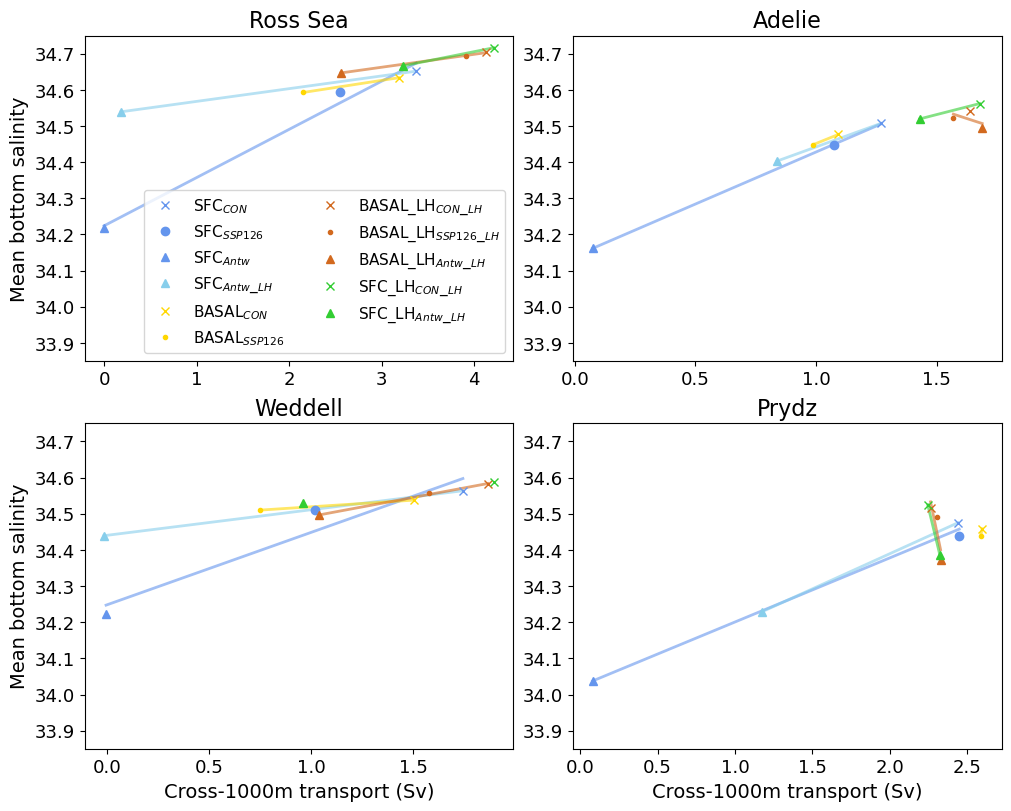

In [95]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), layout="constrained")


sfc_x = np.array([DswExp_ross,DswExp_ross_ssp,DswExp_ross_antw])
sfc_y = np.array([mean_bottom_tracer(salt_ross),mean_bottom_tracer(salt_ross_ssp),mean_bottom_tracer(salt_ross_antw)])
add_regression(ax[0,0], sfc_x, sfc_y, color='cornflowerblue')

sfc_x = np.array([DswExp_ross,DswExp_ross_antw_LH])
sfc_y = np.array([mean_bottom_tracer(salt_ross),mean_bottom_tracer(salt_ross_antw_LH)])
add_regression(ax[0,0], sfc_x, sfc_y, color='skyblue')

sfc_x = np.array([DswExp_ross_basal,DswExp_ross_basal_ssp])
sfc_y = np.array([mean_bottom_tracer(salt_ross_basal),mean_bottom_tracer(salt_ross_basal_ssp)])
add_regression(ax[0,0], sfc_x, sfc_y, color='gold')

sfc_x = np.array([DswExp_ross_basalLH,DswExp_ross_basalLH_ssp,DswExp_ross_basalLH_antw])
sfc_y = np.array([mean_bottom_tracer(salt_ross_basalLH),mean_bottom_tracer(salt_ross_basalLH_ssp),mean_bottom_tracer(salt_ross_basalLH_antw)])
add_regression(ax[0,0], sfc_x, sfc_y, color='chocolate')

sfc_x = np.array([DswExp_ross_LH,DswExp_ross_LH_antw])
sfc_y = np.array([mean_bottom_tracer(salt_ross_LH),mean_bottom_tracer(salt_ross_LH_antw)])
add_regression(ax[0,0], sfc_x, sfc_y, color='limegreen')

ax[0,0].plot(DswExp_ross, np.nanmean(np.nanmean(salt_ross.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='cornflowerblue',label=r'SFC$_{CON}$')
ax[0,0].plot(DswExp_ross_ssp, np.nanmean(np.nanmean(salt_ross_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'o',color='cornflowerblue',label=r'SFC$_{SSP126}$')
ax[0,0].plot(DswExp_ross_antw, np.nanmean(np.nanmean(salt_ross_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='cornflowerblue',label=r'SFC$_{Antw}$')
ax[0,0].plot(DswExp_ross_antw_LH, np.nanmean(np.nanmean(salt_ross_antw_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='skyblue',label=r'SFC$_{Antw}$_$_{LH}$')

ax[0,0].plot(DswExp_ross_basal, np.nanmean(np.nanmean(salt_ross_basal.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='gold',label=r'BASAL$_{CON}$')
ax[0,0].plot(DswExp_ross_basal_ssp, np.nanmean(np.nanmean(salt_ross_basal_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='gold',label=r'BASAL$_{SSP126}$')

ax[0,0].plot(DswExp_ross_basalLH, np.nanmean(np.nanmean(salt_ross_basalLH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='chocolate',label=r'BASAL_LH$_{CON}$_$_{LH}$')
ax[0,0].plot(DswExp_ross_basalLH_ssp, np.nanmean(np.nanmean(salt_ross_basalLH_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='chocolate',label=r'BASAL_LH$_{SSP126}$_$_{LH}$')
ax[0,0].plot(DswExp_ross_basalLH_antw, np.nanmean(np.nanmean(salt_ross_basalLH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='chocolate',label=r'BASAL_LH$_{Antw}$_$_{LH}$')

ax[0,0].plot(DswExp_ross_LH, np.nanmean(np.nanmean(salt_ross_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='limegreen',label=r'SFC_LH$_{CON}$_$_{LH}$')
ax[0,0].plot(DswExp_ross_LH_antw, np.nanmean(np.nanmean(salt_ross_LH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='limegreen',label=r'SFC_LH$_{Antw}$_$_{LH}$')

ax[0,0].legend(ncol=2,fontsize=11)
ax[0,0].set_ylabel('Mean bottom salinity',fontsize=14)
# ax[0,0].set_xlabel('DSW export')
ax[0,0].set_title('Ross Sea',fontsize=16)

# =============================================================================

sfc_x = np.array([DswExp_adelie,DswExp_adelie_ssp,DswExp_adelie_antw])
sfc_y = np.array([mean_bottom_tracer(salt_adelie),mean_bottom_tracer(salt_adelie_ssp),mean_bottom_tracer(salt_adelie_antw)])
add_regression(ax[0,1], sfc_x, sfc_y, color='cornflowerblue')

sfc_x = np.array([DswExp_adelie,DswExp_adelie_antw_LH])
sfc_y = np.array([mean_bottom_tracer(salt_adelie),mean_bottom_tracer(salt_adelie_antw_LH)])
add_regression(ax[0,1], sfc_x, sfc_y, color='skyblue')

sfc_x = np.array([DswExp_adelie_basal,DswExp_adelie_basal_ssp])
sfc_y = np.array([mean_bottom_tracer(salt_adelie_basal),mean_bottom_tracer(salt_adelie_basal_ssp)])
add_regression(ax[0,1], sfc_x, sfc_y, color='gold')

sfc_x = np.array([DswExp_adelie_basalLH,DswExp_adelie_basalLH_ssp,DswExp_adelie_basalLH_antw])
sfc_y = np.array([mean_bottom_tracer(salt_adelie_basalLH),mean_bottom_tracer(salt_adelie_basalLH_ssp),mean_bottom_tracer(salt_adelie_basalLH_antw)])
add_regression(ax[0,1], sfc_x, sfc_y, color='chocolate')

sfc_x = np.array([DswExp_adelie_LH,DswExp_adelie_LH_antw])
sfc_y = np.array([mean_bottom_tracer(salt_adelie_LH),mean_bottom_tracer(salt_adelie_LH_antw)])
add_regression(ax[0,1], sfc_x, sfc_y, color='limegreen')

ax[0,1].plot(DswExp_adelie, np.nanmean(np.nanmean(salt_adelie.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='cornflowerblue',label=r'SFC$_{CON}$')
ax[0,1].plot(DswExp_adelie_ssp, np.nanmean(np.nanmean(salt_adelie_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'o',color='cornflowerblue',label=r'SFC$_{SSP126}$')
ax[0,1].plot(DswExp_adelie_antw, np.nanmean(np.nanmean(salt_adelie_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='cornflowerblue',label=r'SFC$_{Antw}$')
ax[0,1].plot(DswExp_adelie_antw_LH, np.nanmean(np.nanmean(salt_adelie_antw_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='skyblue',label=r'SFC$_{Antw}$_$_{LH}$')

ax[0,1].plot(DswExp_adelie_basal, np.nanmean(np.nanmean(salt_adelie_basal.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='gold',label=r'BASAL$_{CON}$')
ax[0,1].plot(DswExp_adelie_basal_ssp, np.nanmean(np.nanmean(salt_adelie_basal_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='gold',label=r'BASAL$_{SSP126}$')

ax[0,1].plot(DswExp_adelie_basalLH, np.nanmean(np.nanmean(salt_adelie_basalLH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='chocolate',label=r'BASAL_LH$_{CON}$_$_{LH}$')
ax[0,1].plot(DswExp_adelie_basalLH_ssp, np.nanmean(np.nanmean(salt_adelie_basalLH_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='chocolate',label=r'BASAL_LH$_{SSP126}$_$_{LH}$')
ax[0,1].plot(DswExp_adelie_basalLH_antw, np.nanmean(np.nanmean(salt_adelie_basalLH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='chocolate',label=r'BASAL_LH$_{Antw}$_$_{LH}$')

ax[0,1].plot(DswExp_adelie_LH, np.nanmean(np.nanmean(salt_adelie_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='limegreen',label=r'SFC_LH$_{CON}$_$_{LH}$')
ax[0,1].plot(DswExp_adelie_LH_antw, np.nanmean(np.nanmean(salt_adelie_LH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='limegreen',label=r'SFC_LH$_{Antw}$_$_{LH}$')

# # ax[0,1].legend(ncol=2)
# ax[0,1].set_ylabel('Bottom salinity')
# ax[0,1].set_xlabel('DSW export')
ax[0,1].set_title('Adelie',fontsize=16)

# =============================================================================

sfc_x = np.array([DswExp_weddell,DswExp_weddell_ssp,DswExp_weddell_antw])
sfc_y = np.array([mean_bottom_tracer(salt_weddell),mean_bottom_tracer(salt_weddell_ssp),mean_bottom_tracer(salt_weddell_antw)])
add_regression(ax[1,0], sfc_x, sfc_y, color='cornflowerblue')

sfc_x = np.array([DswExp_weddell,DswExp_weddell_antw_LH])
sfc_y = np.array([mean_bottom_tracer(salt_weddell),mean_bottom_tracer(salt_weddell_antw_LH)])
add_regression(ax[1,0], sfc_x, sfc_y, color='skyblue')

sfc_x = np.array([DswExp_weddell_basal,DswExp_weddell_basal_ssp])
sfc_y = np.array([mean_bottom_tracer(salt_weddell_basal),mean_bottom_tracer(salt_weddell_basal_ssp)])
add_regression(ax[1,0], sfc_x, sfc_y, color='gold')

sfc_x = np.array([DswExp_weddell_basalLH,DswExp_weddell_basalLH_ssp,DswExp_weddell_basalLH_antw])
sfc_y = np.array([mean_bottom_tracer(salt_weddell_basalLH),mean_bottom_tracer(salt_weddell_basalLH_ssp),mean_bottom_tracer(salt_weddell_basalLH_antw)])
add_regression(ax[1,0], sfc_x, sfc_y, color='chocolate')

sfc_x = np.array([DswExp_weddell_LH,DswExp_weddell_LH_antw])
sfc_y = np.array([mean_bottom_tracer(salt_weddell_LH),mean_bottom_tracer(salt_weddell_LH_antw)])
# add_regression(ax[1,0], sfc_x, sfc_y, color='limegreen')

ax[1,0].plot(DswExp_weddell, np.nanmean(np.nanmean(salt_weddell.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='cornflowerblue',label=r'SFC$_{CON}$')
ax[1,0].plot(DswExp_weddell_ssp, np.nanmean(np.nanmean(salt_weddell_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'o',color='cornflowerblue',label=r'SFC$_{SSP126}$')
ax[1,0].plot(DswExp_weddell_antw, np.nanmean(np.nanmean(salt_weddell_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='cornflowerblue',label=r'SFC$_{Antw}$')
ax[1,0].plot(DswExp_weddell_antw_LH, np.nanmean(np.nanmean(salt_weddell_antw_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='skyblue',label=r'SFC$_{Antw}$_$_{LH}$')

ax[1,0].plot(DswExp_weddell_basal, np.nanmean(np.nanmean(salt_weddell_basal.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='gold',label=r'BASAL$_{CON}$')
ax[1,0].plot(DswExp_weddell_basal_ssp, np.nanmean(np.nanmean(salt_weddell_basal_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='gold',label=r'BASAL$_{SSP126}$')

ax[1,0].plot(DswExp_weddell_basalLH, np.nanmean(np.nanmean(salt_weddell_basalLH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='chocolate',label=r'BASAL_LH$_{CON}$_$_{LH}$')
ax[1,0].plot(DswExp_weddell_basalLH_ssp, np.nanmean(np.nanmean(salt_weddell_basalLH_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='chocolate',label=r'BASAL_LH$_{SSP126}$_$_{LH}$')
ax[1,0].plot(DswExp_weddell_basalLH_antw, np.nanmean(np.nanmean(salt_weddell_basalLH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='chocolate',label=r'BASAL_LH$_{Antw}$_$_{LH}$')

ax[1,0].plot(DswExp_weddell_LH, np.nanmean(np.nanmean(salt_weddell_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='limegreen',label=r'SFC_LH$_{CON}$')
ax[1,0].plot(DswExp_weddell_LH_antw, np.nanmean(np.nanmean(salt_weddell_LH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='limegreen',label=r'SFC_LH$_{Antw}$_$_{LH}$')

# # ax[1,0].legend(ncol=2)
ax[1,0].set_ylabel('Mean bottom salinity',fontsize=14)
ax[1,0].set_xlabel('Cross-1000m transport (Sv)',fontsize=14)
ax[1,0].set_title('Weddell',fontsize=16)

# =============================================================================

sfc_x = np.array([DswExp_prydz,DswExp_prydz_ssp,DswExp_prydz_antw])
sfc_y = np.array([mean_bottom_tracer(salt_prydz),mean_bottom_tracer(salt_prydz_ssp),mean_bottom_tracer(salt_prydz_antw)])
add_regression(ax[1,1], sfc_x, sfc_y, color='cornflowerblue')

sfc_x = np.array([DswExp_prydz,DswExp_prydz_antw_LH])
sfc_y = np.array([mean_bottom_tracer(salt_prydz),mean_bottom_tracer(salt_prydz_antw_LH)])
add_regression(ax[1,1], sfc_x, sfc_y, color='skyblue')

sfc_x = np.array([DswExp_prydz_basal,DswExp_prydz_basal_ssp])
sfc_y = np.array([mean_bottom_tracer(salt_prydz_basal),mean_bottom_tracer(salt_prydz_basal_ssp)])
add_regression(ax[1,1], sfc_x, sfc_y, color='gold')

sfc_x = np.array([DswExp_prydz_basalLH,DswExp_prydz_basalLH_ssp,DswExp_prydz_basalLH_antw])
sfc_y = np.array([mean_bottom_tracer(salt_prydz_basalLH),mean_bottom_tracer(salt_prydz_basalLH_ssp),mean_bottom_tracer(salt_prydz_basalLH_antw)])
add_regression(ax[1,1], sfc_x, sfc_y, color='chocolate')

sfc_x = np.array([DswExp_prydz_LH,DswExp_prydz_LH_antw])
sfc_y = np.array([mean_bottom_tracer(salt_prydz_LH),mean_bottom_tracer(salt_prydz_LH_antw)])
add_regression(ax[1,1], sfc_x, sfc_y, color='limegreen')

ax[1,1].plot(DswExp_prydz, np.nanmean(np.nanmean(salt_prydz.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='cornflowerblue',label=r'SFC$_{CON}$')
ax[1,1].plot(DswExp_prydz_ssp, np.nanmean(np.nanmean(salt_prydz_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'o',color='cornflowerblue',label=r'SFC$_{SSP126}$')
ax[1,1].plot(DswExp_prydz_antw, np.nanmean(np.nanmean(salt_prydz_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='cornflowerblue',label=r'SFC$_{Antw}$')
ax[1,1].plot(DswExp_prydz_antw_LH, np.nanmean(np.nanmean(salt_prydz_antw_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='skyblue',label=r'SFC$_{Antw}$_$_{LH}$')

ax[1,1].plot(DswExp_prydz_basal, np.nanmean(np.nanmean(salt_prydz_basal.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='gold',label=r'BASAL$_{CON}$')
ax[1,1].plot(DswExp_prydz_basal_ssp, np.nanmean(np.nanmean(salt_prydz_basal_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='gold',label=r'BASAL$_{SSP126}$')

ax[1,1].plot(DswExp_prydz_basalLH, np.nanmean(np.nanmean(salt_prydz_basalLH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='chocolate',label=r'BASAL_LH$_{CON}$_$_{LH}$')
ax[1,1].plot(DswExp_prydz_basalLH_ssp, np.nanmean(np.nanmean(salt_prydz_basalLH_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='chocolate',label=r'BASAL_LH$_{SSP126$_$_{LH}}$')
ax[1,1].plot(DswExp_prydz_basalLH_antw, np.nanmean(np.nanmean(salt_prydz_basalLH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='chocolate',label=r'BASAL_LH$_{Antw}$_$_{LH}$')

ax[1,1].plot(DswExp_prydz_LH, np.nanmean(np.nanmean(salt_prydz_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='limegreen',label=r'SFC_LH$_{CON}$_$_{LH}$')
ax[1,1].plot(DswExp_prydz_LH_antw, np.nanmean(np.nanmean(salt_prydz_LH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='limegreen',label=r'SFC_LH$_{Antw}$_$_{LH}$')

# # ax[1,1].legend(ncol=2)
# ax[1,1].set_ylabel('Bottom salinity')
ax[1,1].set_xlabel('Cross-1000m transport (Sv)',fontsize=14)
ax[1,1].set_title('Prydz',fontsize=16)

for i in range(0,2):
    for j in range(0,2):
        ax[i,j].tick_params(axis='x', labelsize=13)
        ax[i,j].tick_params(axis='y', labelsize=13)
        ax[i,j].set_ylim(33.85,34.75)
        # ax[i,j].set_xlim(-.1,4.)


# plt.savefig(figdir+'Relation_DSWexportXbottom_salt.png',bbox_inches='tight',dpi=300)
plt.savefig(figdir+'Relation_DSWexportXbottom_salt_Regression.png',bbox_inches='tight',dpi=300)
plt.show()

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), layout="constrained")


sfc_x = np.array([DswExp_ross,DswExp_ross_ssp,DswExp_ross_antw])
sfc_y = np.array([mean_bottom_tracer(temp_ross)-273.15,mean_bottom_tracer(temp_ross_ssp)-273.15,mean_bottom_tracer(temp_ross_antw)-273.15])
add_regression(ax[0,0], sfc_x, sfc_y, color='cornflowerblue')

sfc_x = np.array([DswExp_ross,DswExp_ross_antw_LH])
sfc_y = np.array([mean_bottom_tracer(temp_ross)-273.15,mean_bottom_tracer(temp_ross_antw_LH)-273.15])
add_regression(ax[0,0], sfc_x, sfc_y, color='skyblue')

sfc_x = np.array([DswExp_ross_basal,DswExp_ross_basal_ssp])
sfc_y = np.array([mean_bottom_tracer(temp_ross_basal)-273.15,mean_bottom_tracer(temp_ross_basal_ssp)-273.15])
add_regression(ax[0,0], sfc_x, sfc_y, color='gold')

sfc_x = np.array([DswExp_ross_basalLH,DswExp_ross_basalLH_ssp,DswExp_ross_basalLH_antw])
sfc_y = np.array([mean_bottom_tracer(temp_ross_basalLH)-273.15,mean_bottom_tracer(temp_ross_basalLH_ssp)-273.15,mean_bottom_tracer(temp_ross_basalLH_antw)-273.15])
add_regression(ax[0,0], sfc_x, sfc_y, color='chocolate')

sfc_x = np.array([DswExp_ross_LH,DswExp_ross_LH_antw])
sfc_y = np.array([mean_bottom_tracer(temp_ross_LH)-273.15,mean_bottom_tracer(temp_ross_LH_antw)-273.15])
add_regression(ax[0,0], sfc_x, sfc_y, color='limegreen')

ax[0,0].plot(DswExp_ross, np.nanmean(np.nanmean(temp_ross.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='cornflowerblue',label=r'SFC$_{CON}$')
ax[0,0].plot(DswExp_ross_ssp, np.nanmean(np.nanmean(temp_ross_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'o',color='cornflowerblue',label=r'SFC$_{SSP126}$')
ax[0,0].plot(DswExp_ross_antw, np.nanmean(np.nanmean(temp_ross_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='cornflowerblue',label=r'SFC$_{Antw}$')
ax[0,0].plot(DswExp_ross_antw_LH, np.nanmean(np.nanmean(temp_ross_antw_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='skyblue',label=r'SFC$_{Antw}$_$_{LH}$')

ax[0,0].plot(DswExp_ross_basal, np.nanmean(np.nanmean(temp_ross_basal.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='gold',label=r'BASAL$_{CON}$')
ax[0,0].plot(DswExp_ross_basal_ssp, np.nanmean(np.nanmean(temp_ross_basal_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '.',color='gold',label=r'BASAL$_{SSP126}$')

ax[0,0].plot(DswExp_ross_basalLH, np.nanmean(np.nanmean(temp_ross_basalLH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='chocolate',label=r'BASAL_LH$_{CON}$_$_{LH}$')
ax[0,0].plot(DswExp_ross_basalLH_ssp, np.nanmean(np.nanmean(temp_ross_basalLH_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '.',color='chocolate',label=r'BASAL_LH$_{SSP126}$_$_{LH}$')
ax[0,0].plot(DswExp_ross_basalLH_antw, np.nanmean(np.nanmean(temp_ross_basalLH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='chocolate',label=r'BASAL_LH$_{Antw}$_$_{LH}$')

ax[0,0].plot(DswExp_ross_LH, np.nanmean(np.nanmean(temp_ross_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='limegreen',label=r'SFC_LH$_{CON}$_$_{LH}$')
ax[0,0].plot(DswExp_ross_LH_antw, np.nanmean(np.nanmean(temp_ross_LH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='limegreen',label=r'SFC_LH$_{Antw}$_$_{LH}$')

ax[0,0].legend(ncol=2,fontsize=11)
ax[0,0].set_ylabel('Mean bottom temperature',fontsize=14)
# ax[0,0].set_xlabel('DSW export')
ax[0,0].set_title('Ross Sea',fontsize=16)

# =============================================================================

sfc_x = np.array([DswExp_adelie,DswExp_adelie_ssp,DswExp_adelie_antw])
sfc_y = np.array([mean_bottom_tracer(temp_adelie)-273.15,mean_bottom_tracer(temp_adelie_ssp)-273.15,mean_bottom_tracer(temp_adelie_antw)-273.15])
add_regression(ax[0,1], sfc_x, sfc_y, color='cornflowerblue')

sfc_x = np.array([DswExp_adelie,DswExp_adelie_antw_LH])
sfc_y = np.array([mean_bottom_tracer(temp_adelie)-273.15,mean_bottom_tracer(temp_adelie_antw_LH)-273.15])
add_regression(ax[0,1], sfc_x, sfc_y, color='skyblue')

sfc_x = np.array([DswExp_adelie_basal,DswExp_adelie_basal_ssp])
sfc_y = np.array([mean_bottom_tracer(temp_adelie_basal)-273.15,mean_bottom_tracer(temp_adelie_basal_ssp)-273.15])
add_regression(ax[0,1], sfc_x, sfc_y, color='gold')

sfc_x = np.array([DswExp_adelie_basalLH,DswExp_adelie_basalLH_ssp,DswExp_adelie_basalLH_antw])
sfc_y = np.array([mean_bottom_tracer(temp_adelie_basalLH)-273.15,mean_bottom_tracer(temp_adelie_basalLH_ssp)-273.15,mean_bottom_tracer(temp_adelie_basalLH_antw)-273.15])
add_regression(ax[0,1], sfc_x, sfc_y, color='chocolate')

sfc_x = np.array([DswExp_adelie_LH,DswExp_adelie_LH_antw])
sfc_y = np.array([mean_bottom_tracer(temp_adelie_LH)-273.15,mean_bottom_tracer(temp_adelie_LH_antw)-273.15])
add_regression(ax[0,1], sfc_x, sfc_y, color='limegreen')

ax[0,1].plot(DswExp_adelie, np.nanmean(np.nanmean(temp_adelie.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='cornflowerblue',label=r'SFC$_{CON}$')
ax[0,1].plot(DswExp_adelie_ssp, np.nanmean(np.nanmean(temp_adelie_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'o',color='cornflowerblue',label=r'SFC$_{SSP126}$')
ax[0,1].plot(DswExp_adelie_antw, np.nanmean(np.nanmean(temp_adelie_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='cornflowerblue',label=r'SFC$_{Antw}$')
ax[0,1].plot(DswExp_adelie_antw_LH, np.nanmean(np.nanmean(temp_adelie_antw_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='skyblue',label=r'SFC$_{Antw}$_$_{LH}$')

ax[0,1].plot(DswExp_adelie_basal, np.nanmean(np.nanmean(temp_adelie_basal.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='gold',label=r'BASAL$_{CON}$')
ax[0,1].plot(DswExp_adelie_basal_ssp, np.nanmean(np.nanmean(temp_adelie_basal_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '.',color='gold',label=r'BASAL$_{SSP126}$')

ax[0,1].plot(DswExp_adelie_basalLH, np.nanmean(np.nanmean(temp_adelie_basalLH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='chocolate',label=r'BASAL_LH$_{CON}$_$_{LH}$')
ax[0,1].plot(DswExp_adelie_basalLH_ssp, np.nanmean(np.nanmean(temp_adelie_basalLH_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '.',color='chocolate',label=r'BASAL_LH$_{SSP126}$_$_{LH}$')
ax[0,1].plot(DswExp_adelie_basalLH_antw, np.nanmean(np.nanmean(temp_adelie_basalLH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='chocolate',label=r'BASAL_LH$_{Antw}$_$_{LH}$')

ax[0,1].plot(DswExp_adelie_LH, np.nanmean(np.nanmean(temp_adelie_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='limegreen',label=r'SFC_LH$_{CON}$_$_{LH}$')
ax[0,1].plot(DswExp_adelie_LH_antw, np.nanmean(np.nanmean(temp_adelie_LH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='limegreen',label=r'SFC_LH$_{Antw}$_$_{LH}$')

# # ax[0,1].legend(ncol=2)
# ax[0,1].set_ylabel('Bottom temperature')
# ax[0,1].set_xlabel('DSW export')
ax[0,1].set_title('Adelie',fontsize=16)

# =============================================================================

sfc_x = np.array([DswExp_weddell,DswExp_weddell_ssp,DswExp_weddell_antw])
sfc_y = np.array([mean_bottom_tracer(temp_weddell)-273.15,mean_bottom_tracer(temp_weddell_ssp)-273.15,mean_bottom_tracer(temp_weddell_antw)-273.15])
add_regression(ax[1,0], sfc_x, sfc_y, color='cornflowerblue')

sfc_x = np.array([DswExp_weddell,DswExp_weddell_antw_LH])
sfc_y = np.array([mean_bottom_tracer(temp_weddell)-273.15,mean_bottom_tracer(temp_weddell_antw_LH)-273.15])
add_regression(ax[1,0], sfc_x, sfc_y, color='skyblue')

sfc_x = np.array([DswExp_weddell_basal,DswExp_weddell_basal_ssp])
sfc_y = np.array([mean_bottom_tracer(temp_weddell_basal)-273.15,mean_bottom_tracer(temp_weddell_basal_ssp)-273.15])
add_regression(ax[1,0], sfc_x, sfc_y, color='gold')

sfc_x = np.array([DswExp_weddell_basalLH,DswExp_weddell_basalLH_ssp,DswExp_weddell_basalLH_antw])
sfc_y = np.array([mean_bottom_tracer(temp_weddell_basalLH)-273.15,mean_bottom_tracer(temp_weddell_basalLH_ssp)-273.15,mean_bottom_tracer(temp_weddell_basalLH_antw)-273.15])
add_regression(ax[1,0], sfc_x, sfc_y, color='chocolate')

sfc_x = np.array([DswExp_weddell_LH,DswExp_weddell_LH_antw])
sfc_y = np.array([mean_bottom_tracer(temp_weddell_LH)-273.15,mean_bottom_tracer(temp_weddell_LH_antw)-273.15])
add_regression(ax[1,0], sfc_x, sfc_y, color='limegreen')

ax[1,0].plot(DswExp_weddell, np.nanmean(np.nanmean(temp_weddell.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='cornflowerblue',label=r'SFC$_{CON}$')
ax[1,0].plot(DswExp_weddell_ssp, np.nanmean(np.nanmean(temp_weddell_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'o',color='cornflowerblue',label=r'SFC$_{SSP126}$')
ax[1,0].plot(DswExp_weddell_antw, np.nanmean(np.nanmean(temp_weddell_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='cornflowerblue',label=r'SFC$_{Antw}$')
ax[1,0].plot(DswExp_weddell_antw_LH, np.nanmean(np.nanmean(temp_weddell_antw_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='skyblue',label=r'SFC$_{Antw}$_$_{LH}$')

ax[1,0].plot(DswExp_weddell_basal, np.nanmean(np.nanmean(temp_weddell_basal.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='gold',label=r'BASAL$_{CON}$')
ax[1,0].plot(DswExp_weddell_basal_ssp, np.nanmean(np.nanmean(temp_weddell_basal_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '.',color='gold',label=r'BASAL$_{SSP126}$')

ax[1,0].plot(DswExp_weddell_basalLH, np.nanmean(np.nanmean(temp_weddell_basalLH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='chocolate',label=r'BASAL_LH$_{CON}$_$_{LH}$')
ax[1,0].plot(DswExp_weddell_basalLH_ssp, np.nanmean(np.nanmean(temp_weddell_basalLH_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '.',color='chocolate',label=r'BASAL_LH$_{SSP126}$_$_{LH}$')
ax[1,0].plot(DswExp_weddell_basalLH_antw, np.nanmean(np.nanmean(temp_weddell_basalLH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='chocolate',label=r'BASAL_LH$_{Antw}$_$_{LH}$')

ax[1,0].plot(DswExp_weddell_LH, np.nanmean(np.nanmean(temp_weddell_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='limegreen',label=r'SFC_LH$_{CON}$')
ax[1,0].plot(DswExp_weddell_LH_antw, np.nanmean(np.nanmean(temp_weddell_LH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='limegreen',label=r'SFC_LH$_{Antw}$_$_{LH}$')

# # ax[1,0].legend(ncol=2)
ax[1,0].set_ylabel('Mean bottom temperature',fontsize=14)
ax[1,0].set_xlabel('Cross-1000m transport (Sv)',fontsize=14)
ax[1,0].set_title('Weddell',fontsize=16)

# =============================================================================

sfc_x = np.array([DswExp_prydz,DswExp_prydz_ssp,DswExp_prydz_antw])
sfc_y = np.array([mean_bottom_tracer(temp_prydz),mean_bottom_tracer(temp_prydz_ssp)-273.15,mean_bottom_tracer(temp_prydz_antw)-273.15])
add_regression(ax[1,1], sfc_x, sfc_y, color='cornflowerblue')

sfc_x = np.array([DswExp_prydz,DswExp_prydz_antw_LH])
sfc_y = np.array([mean_bottom_tracer(temp_prydz)-273.15,mean_bottom_tracer(temp_prydz_antw_LH)-273.15])
add_regression(ax[1,1], sfc_x, sfc_y, color='skyblue')

sfc_x = np.array([DswExp_prydz_basal,DswExp_prydz_basal_ssp])
sfc_y = np.array([mean_bottom_tracer(temp_prydz_basal)-273.15,mean_bottom_tracer(temp_prydz_basal_ssp)-273.15])
add_regression(ax[1,1], sfc_x, sfc_y, color='gold')

sfc_x = np.array([DswExp_prydz_basalLH,DswExp_prydz_basalLH_ssp,DswExp_prydz_basalLH_antw])
sfc_y = np.array([mean_bottom_tracer(temp_prydz_basalLH)-273.15,mean_bottom_tracer(temp_prydz_basalLH_ssp)-273.15,mean_bottom_tracer(temp_prydz_basalLH_antw)-273.15])
add_regression(ax[1,1], sfc_x, sfc_y, color='chocolate')

sfc_x = np.array([DswExp_prydz_LH,DswExp_prydz_LH_antw])
sfc_y = np.array([mean_bottom_tracer(temp_prydz_LH)-273.15,mean_bottom_tracer(temp_prydz_LH_antw)-273.15])
add_regression(ax[1,1], sfc_x, sfc_y, color='limegreen')

ax[1,1].plot(DswExp_prydz, np.nanmean(np.nanmean(temp_prydz.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='cornflowerblue',label=r'SFC$_{CON}$')
ax[1,1].plot(DswExp_prydz_ssp, np.nanmean(np.nanmean(temp_prydz_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'o',color='cornflowerblue',label=r'SFC$_{SSP126}$')
ax[1,1].plot(DswExp_prydz_antw, np.nanmean(np.nanmean(temp_prydz_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='cornflowerblue',label=r'SFC$_{Antw}$')
ax[1,1].plot(DswExp_prydz_antw_LH, np.nanmean(np.nanmean(temp_prydz_antw_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='skyblue',label=r'SFC$_{Antw}$_$_{LH}$')

ax[1,1].plot(DswExp_prydz_basal, np.nanmean(np.nanmean(temp_prydz_basal.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='gold',label=r'BASAL$_{CON}$')
ax[1,1].plot(DswExp_prydz_basal_ssp, np.nanmean(np.nanmean(temp_prydz_basal_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '.',color='gold',label=r'BASAL$_{SSP126}$')

ax[1,1].plot(DswExp_prydz_basalLH, np.nanmean(np.nanmean(temp_prydz_basalLH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='chocolate',label=r'BASAL_LH$_{CON}$_$_{LH}$')
ax[1,1].plot(DswExp_prydz_basalLH_ssp, np.nanmean(np.nanmean(temp_prydz_basalLH_ssp.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '.',color='chocolate',label=r'BASAL_LH$_{SSP126$_$_{LH}}$')
ax[1,1].plot(DswExp_prydz_basalLH_antw, np.nanmean(np.nanmean(temp_prydz_basalLH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='chocolate',label=r'BASAL_LH$_{Antw}$_$_{LH}$')

ax[1,1].plot(DswExp_prydz_LH, np.nanmean(np.nanmean(temp_prydz_LH.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, 'x',color='limegreen',label=r'SFC_LH$_{CON}$_$_{LH}$')
ax[1,1].plot(DswExp_prydz_LH_antw, np.nanmean(np.nanmean(temp_prydz_LH_antw.mean('time').to_dataarray().squeeze(),axis=-1),axis=-1)-273.15, '^',color='limegreen',label=r'SFC_LH$_{Antw}$_$_{LH}$')

# # ax[1,1].legend(ncol=2)
# ax[1,1].set_ylabel('Bottom temperature')
ax[1,1].set_xlabel('Cross-1000m transport (Sv)',fontsize=14)
ax[1,1].set_title('Prydz',fontsize=16)

for i in range(0,2):
    for j in range(0,2):
        ax[i,j].tick_params(axis='x', labelsize=13)
        ax[i,j].tick_params(axis='y', labelsize=13)
        ax[i,j].set_ylim(33.85,34.75)
        # ax[i,j].set_xlim(-.1,4.)


plt.savefig(figdir+'Relation_DSWexportXbottom_temp_Regression.png',bbox_inches='tight',dpi=300)
plt.show()

In [96]:
figdir

'/g/data/e14/fbd581/basal_mom5-collaborative-project/'

## attempt of DSW export X salinity using all points:

Text(0.5, 1.0, 'Ross Sea')

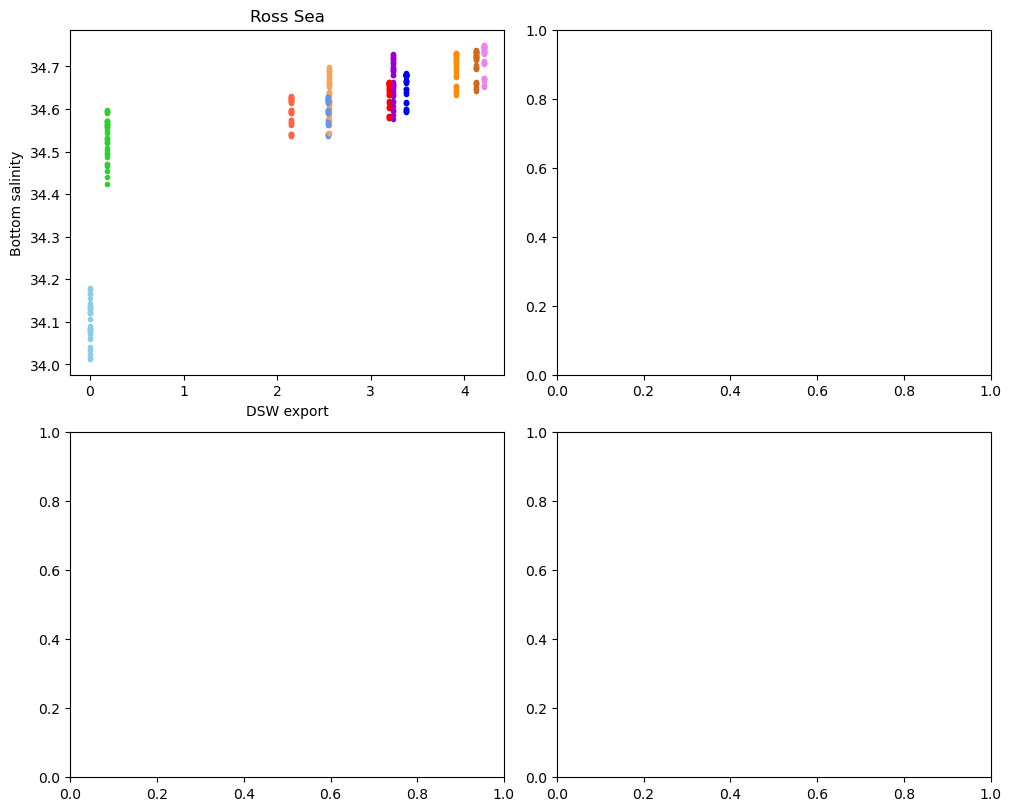

In [49]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), layout="constrained")

for tt in range(0,36):
    ax[0,0].plot(DswExp_ross, np.nanmean(np.nanmean(salt_ross.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='blue',label=r'SFC$_{CON}$')
    ax[0,0].plot(DswExp_ross_ssp, np.nanmean(np.nanmean(salt_ross_ssp.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='cornflowerblue',label=r'SFC$_{SSP126}$')
    ax[0,0].plot(DswExp_ross_antw, np.nanmean(np.nanmean(salt_ross_antw.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='skyblue',label=r'SFC$_{Antw}$')
    
    ax[0,0].plot(DswExp_ross_basal, np.nanmean(np.nanmean(salt_ross_basal.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='r',label=r'BASAL$_{CON}$')
    ax[0,0].plot(DswExp_ross_basal_ssp, np.nanmean(np.nanmean(salt_ross_basal_ssp.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='tomato',label=r'BASAL$_{SSP126}$')
    
    ax[0,0].plot(DswExp_ross_basalLH, np.nanmean(np.nanmean(salt_ross_basalLH.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='chocolate',label=r'BASAL_LH$_{CON}$')
    ax[0,0].plot(DswExp_ross_basalLH_ssp, np.nanmean(np.nanmean(salt_ross_basalLH_ssp.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='darkorange',label=r'BASAL_LH$_{SSP126}$')
    ax[0,0].plot(DswExp_ross_basalLH_antw, np.nanmean(np.nanmean(salt_ross_basalLH_antw.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='sandybrown',label=r'BASAL_LH$_{Antw}$')
    
    ax[0,0].plot(DswExp_ross_LH, np.nanmean(np.nanmean(salt_ross_LH.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='violet',label=r'SFC_LH$_{CON}$')
    ax[0,0].plot(DswExp_ross_LH_antw, np.nanmean(np.nanmean(salt_ross_LH_antw.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='darkviolet',label=r'SFC_LH$_{Antw}$')
    ax[0,0].plot(DswExp_ross_antw_LH, np.nanmean(np.nanmean(salt_ross_antw_LH.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='limegreen',label=r'SFC$_{Antw}$_$_{LH}$')

# ax[0,0].legend(ncol=2)
ax[0,0].set_ylabel('Bottom salinity')
ax[0,0].set_xlabel('DSW export')
ax[0,0].set_title('Ross Sea')

# ax[0,1].plot(DswExp_adelie, np.nanmean(np.nanmean(salt_adelie.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='blue',label=r'SFC$_{CON}$')
# ax[0,1].plot(DswExp_adelie_ssp, np.nanmean(np.nanmean(salt_adelie_ssp.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), 'o',color='cornflowerblue',label=r'SFC$_{SSP126}$')
# ax[0,1].plot(DswExp_adelie_antw, np.nanmean(np.nanmean(salt_adelie_antw.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='skyblue',label=r'SFC$_{Antw}$')

# ax[0,1].plot(DswExp_adelie_basal, np.nanmean(np.nanmean(salt_adelie_basal.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='r',label=r'BASAL$_{CON}$')
# ax[0,1].plot(DswExp_adelie_basal_ssp, np.nanmean(np.nanmean(salt_adelie_basal_ssp.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='tomato',label=r'BASAL$_{SSP126}$')

# ax[0,1].plot(DswExp_adelie_basalLH, np.nanmean(np.nanmean(salt_adelie_basalLH.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='chocolate',label=r'BASAL_LH$_{CON}$')
# ax[0,1].plot(DswExp_adelie_basalLH_ssp, np.nanmean(np.nanmean(salt_adelie_basalLH_ssp.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='darkorange',label=r'BASAL_LH$_{SSP126}$')
# ax[0,1].plot(DswExp_adelie_basalLH_antw, np.nanmean(np.nanmean(salt_adelie_basalLH_antw.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='sandybrown',label=r'BASAL_LH$_{Antw}$')

# ax[0,1].plot(DswExp_adelie_LH, np.nanmean(np.nanmean(salt_adelie_LH.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='violet',label=r'SFC_LH$_{CON}$')
# ax[0,1].plot(DswExp_adelie_LH_antw, np.nanmean(np.nanmean(salt_adelie_LH_antw.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='darkviolet',label=r'SFC_LH$_{Antw}$')
# ax[0,1].plot(DswExp_adelie_antw_LH, np.nanmean(np.nanmean(salt_adelie_antw_LH.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='limegreen',label=r'SFC$_{Antw}$_$_{LH}$')

# # # ax[0,1].legend(ncol=2)
# ax[0,1].set_ylabel('Bottom salinity')
# ax[0,1].set_xlabel('DSW export')
# ax[0,1].set_title('Adelie')

# ax[1,0].plot(DswExp_weddell, np.nanmean(np.nanmean(salt_weddell.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='blue',label=r'SFC$_{CON}$')
# ax[1,0].plot(DswExp_weddell_ssp, np.nanmean(np.nanmean(salt_weddell_ssp.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), 'o',color='cornflowerblue',label=r'SFC$_{SSP126}$')
# ax[1,0].plot(DswExp_weddell_antw, np.nanmean(np.nanmean(salt_weddell_antw.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='skyblue',label=r'SFC$_{Antw}$')

# ax[1,0].plot(DswExp_weddell_basal, np.nanmean(np.nanmean(salt_weddell_basal.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='r',label=r'BASAL$_{CON}$')
# ax[1,0].plot(DswExp_weddell_basal_ssp, np.nanmean(np.nanmean(salt_weddell_basal_ssp.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='tomato',label=r'BASAL$_{SSP126}$')

# ax[1,0].plot(DswExp_weddell_basalLH, np.nanmean(np.nanmean(salt_weddell_basalLH.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='chocolate',label=r'BASAL_LH$_{CON}$')
# ax[1,0].plot(DswExp_weddell_basalLH_ssp, np.nanmean(np.nanmean(salt_weddell_basalLH_ssp.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='darkorange',label=r'BASAL_LH$_{SSP126}$')
# ax[1,0].plot(DswExp_weddell_basalLH_antw, np.nanmean(np.nanmean(salt_weddell_basalLH_antw.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='sandybrown',label=r'BASAL_LH$_{Antw}$')

# ax[1,0].plot(DswExp_weddell_LH, np.nanmean(np.nanmean(salt_weddell_LH.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='violet',label=r'SFC_LH$_{CON}$')
# ax[1,0].plot(DswExp_weddell_LH_antw, np.nanmean(np.nanmean(salt_weddell_LH_antw.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='darkviolet',label=r'SFC_LH$_{Antw}$')
# ax[1,0].plot(DswExp_weddell_antw_LH, np.nanmean(np.nanmean(salt_weddell_antw_LH.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='limegreen',label=r'SFC$_{Antw}$_$_{LH}$')

# # # ax[1,0].legend(ncol=2)
# ax[1,0].set_ylabel('Bottom salinity')
# ax[1,0].set_xlabel('DSW export')
# ax[1,0].set_title('Weddell')

# ax[1,1].plot(DswExp_prydz, np.nanmean(np.nanmean(salt_prydz.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='blue',label=r'SFC$_{CON}$')
# ax[1,1].plot(DswExp_prydz_ssp, np.nanmean(np.nanmean(salt_prydz_ssp.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), 'o',color='cornflowerblue',label=r'SFC$_{SSP126}$')
# ax[1,1].plot(DswExp_prydz_antw, np.nanmean(np.nanmean(salt_prydz_antw.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='skyblue',label=r'SFC$_{Antw}$')

# ax[1,1].plot(DswExp_prydz_basal, np.nanmean(np.nanmean(salt_prydz_basal.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='r',label=r'BASAL$_{CON}$')
# ax[1,1].plot(DswExp_prydz_basal_ssp, np.nanmean(np.nanmean(salt_prydz_basal_ssp.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='tomato',label=r'BASAL$_{SSP126}$')

# ax[1,1].plot(DswExp_prydz_basalLH, np.nanmean(np.nanmean(salt_prydz_basalLH.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='chocolate',label=r'BASAL_LH$_{CON}$')
# ax[1,1].plot(DswExp_prydz_basalLH_ssp, np.nanmean(np.nanmean(salt_prydz_basalLH_ssp.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '.',color='darkorange',label=r'BASAL_LH$_{SSP126}$')
# ax[1,1].plot(DswExp_prydz_basalLH_antw, np.nanmean(np.nanmean(salt_prydz_basalLH_antw.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='sandybrown',label=r'BASAL_LH$_{Antw}$')

# ax[1,1].plot(DswExp_prydz_LH, np.nanmean(np.nanmean(salt_prydz_LH.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), 'x',color='violet',label=r'SFC_LH$_{CON}$')
# ax[1,1].plot(DswExp_prydz_LH_antw, np.nanmean(np.nanmean(salt_prydz_LH_antw.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='darkviolet',label=r'SFC_LH$_{Antw}$')
# ax[1,1].plot(DswExp_prydz_antw_LH, np.nanmean(np.nanmean(salt_prydz_antw_LH.isel(time=tt).to_dataarray().squeeze(),axis=-1),axis=-1), '^',color='limegreen',label=r'SFC$_{Antw}$_$_{LH}$')

# # # ax[1,1].legend(ncol=2)
# ax[1,1].set_ylabel('Bottom salinity')
# ax[1,1].set_xlabel('DSW export')
# ax[1,1].set_title('Prydz')

# plt.savefig(figdir+'Relation_DSWexportXbottom_salt_allpoints.png',bbox_inches='tight',dpi=300)
# plt.show()

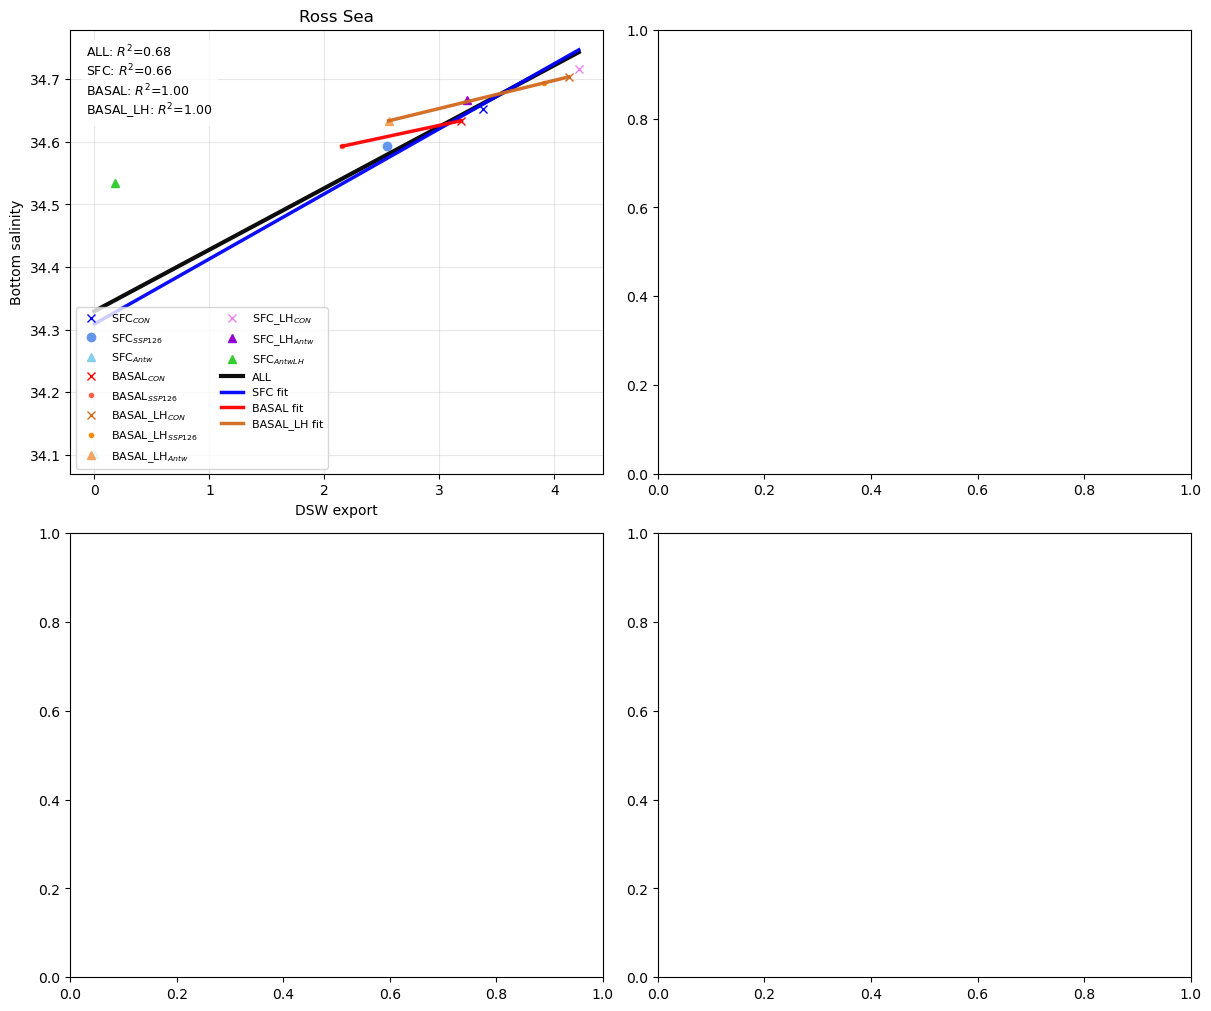

In [51]:
# ==========================================================
# DSW export vs bottom salinity
# PRESERVING ORIGINAL COLORS + MARKERS
# and adding:
#   - regression lines
#   - R² values
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ==========================================================
# Helper functions
# ==========================================================

def mean_bottom_salt(ds):

    return np.nanmean(
        np.nanmean(
            ds.mean('time').to_dataarray().squeeze(),
            axis=-1
        ),
        axis=-1
    )


def add_regression(ax, x, y, color, lw=2.5, label=None):

    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)

    x = x[mask]
    y = y[mask]

    reg = linregress(x, y)

    slope = reg.slope
    intercept = reg.intercept
    r2 = reg.rvalue**2

    xx = np.linspace(np.min(x), np.max(x), 100)
    yy = slope * xx + intercept

    ax.plot(
        xx,
        yy,
        color=color,
        lw=lw,
        alpha=0.95,
        label=label
    )

    return reg, r2


# ==========================================================
# PANEL FUNCTION
# ==========================================================

def make_panel(
    ax,
    title,
    x_sfc,
    y_sfc,
    x_basal,
    y_basal,
    x_basalLH,
    y_basalLH
):

    # ======================================================
    # REGRESSIONS
    # ======================================================

    reg_all, r2_all = add_regression(
        ax,
        np.concatenate([x_sfc, x_basal, x_basalLH]),
        np.concatenate([y_sfc, y_basal, y_basalLH]),
        color='k',
        lw=3,
        label='ALL'
    )

    reg_sfc, r2_sfc = add_regression(
        ax,
        x_sfc,
        y_sfc,
        color='blue',
        lw=2.5,
        label='SFC fit'
    )

    reg_basal, r2_basal = add_regression(
        ax,
        x_basal,
        y_basal,
        color='red',
        lw=2.5,
        label='BASAL fit'
    )

    reg_basalLH, r2_basalLH = add_regression(
        ax,
        x_basalLH,
        y_basalLH,
        color='chocolate',
        lw=2.5,
        label='BASAL_LH fit'
    )

    # ======================================================
    # TEXT
    # ======================================================

    txt = (
        f'ALL: $R^2$={r2_all:.2f}\n'
        f'SFC: $R^2$={r2_sfc:.2f}\n'
        f'BASAL: $R^2$={r2_basal:.2f}\n'
        f'BASAL_LH: $R^2$={r2_basalLH:.2f}'
    )

    ax.text(
        0.03,
        0.97,
        txt,
        transform=ax.transAxes,
        fontsize=9,
        va='top',
        bbox=dict(
            facecolor='white',
            alpha=0.8,
            edgecolor='none'
        )
    )

    ax.set_title(title)
    ax.set_xlabel('DSW export')
    ax.set_ylabel('Bottom salinity')
    ax.grid(alpha=0.3)


# ==========================================================
# FIGURE
# ==========================================================

fig, ax = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12,10),
    layout='constrained'
)

# ==========================================================
# ====================== ROSS ==============================
# ==========================================================

# ---------- ORIGINAL SCATTERS ----------

ax[0,0].plot(DswExp_ross,
             mean_bottom_salt(salt_ross),
             'x', color='blue', label=r'SFC$_{CON}$')

ax[0,0].plot(DswExp_ross_ssp,
             mean_bottom_salt(salt_ross_ssp),
             'o', color='cornflowerblue', label=r'SFC$_{SSP126}$')

ax[0,0].plot(DswExp_ross_antw,
             mean_bottom_salt(salt_ross_antw),
             '^', color='skyblue', label=r'SFC$_{Antw}$')

ax[0,0].plot(DswExp_ross_basal,
             mean_bottom_salt(salt_ross_basal),
             'x', color='red', label=r'BASAL$_{CON}$')

ax[0,0].plot(DswExp_ross_basal_ssp,
             mean_bottom_salt(salt_ross_basal_ssp),
             '.', color='tomato', label=r'BASAL$_{SSP126}$')

ax[0,0].plot(DswExp_ross_basalLH,
             mean_bottom_salt(salt_ross_basalLH),
             'x', color='chocolate', label=r'BASAL_LH$_{CON}$')

ax[0,0].plot(DswExp_ross_basalLH_ssp,
             mean_bottom_salt(salt_ross_basalLH_ssp),
             '.', color='darkorange', label=r'BASAL_LH$_{SSP126}$')

ax[0,0].plot(DswExp_ross_basalLH_antw,
             mean_bottom_salt(salt_ross_basalLH_antw),
             '^', color='sandybrown', label=r'BASAL_LH$_{Antw}$')

ax[0,0].plot(DswExp_ross_LH,
             mean_bottom_salt(salt_ross_LH),
             'x', color='violet', label=r'SFC_LH$_{CON}$')

ax[0,0].plot(DswExp_ross_LH_antw,
             mean_bottom_salt(salt_ross_LH_antw),
             '^', color='darkviolet', label=r'SFC_LH$_{Antw}$')

ax[0,0].plot(DswExp_ross_antw_LH,
             mean_bottom_salt(salt_ross_antw_LH),
             '^', color='limegreen', label=r'SFC$_{AntwLH}$')

# ---------- REGRESSIONS ----------

ross_sfc_x = np.array([
    DswExp_ross,
    DswExp_ross_ssp,
    DswExp_ross_antw,
    DswExp_ross_LH,
    DswExp_ross_LH_antw,
    DswExp_ross_antw_LH
])

ross_sfc_y = np.array([
    mean_bottom_salt(salt_ross),
    mean_bottom_salt(salt_ross_ssp),
    mean_bottom_salt(salt_ross_antw),
    mean_bottom_salt(salt_ross_LH),
    mean_bottom_salt(salt_ross_LH_antw),
    mean_bottom_salt(salt_ross_antw_LH)
])

ross_basal_x = np.array([
    DswExp_ross_basal,
    DswExp_ross_basal_ssp
])

ross_basal_y = np.array([
    mean_bottom_salt(salt_ross_basal),
    mean_bottom_salt(salt_ross_basal_ssp)
])

ross_basalLH_x = np.array([
    DswExp_ross_basalLH,
    DswExp_ross_basalLH_ssp,
    DswExp_ross_basalLH_antw
])

ross_basalLH_y = np.array([
    mean_bottom_salt(salt_ross_basalLH),
    mean_bottom_salt(salt_ross_basalLH_ssp),
    mean_bottom_salt(salt_ross_basalLH_antw)
])

make_panel(
    ax[0,0],
    'Ross Sea',
    ross_sfc_x,
    ross_sfc_y,
    ross_basal_x,
    ross_basal_y,
    ross_basalLH_x,
    ross_basalLH_y
)

# ==========================================================
# Repeat EXACT same structure for:
#   - Adelie
#   - Weddell
#   - Prydz
#
# You can directly copy the same plotting block you already
# had and then ONLY update the arrays passed into make_panel
# ==========================================================

# ==========================================================
# LEGEND
# ==========================================================

ax[0,0].legend(
    fontsize=8,
    ncol=2,
    loc='lower left'
)

# ==========================================================
# SAVE
# ==========================================================

plt.savefig(
    figdir + 'DSW_vs_Salinity_regressions.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()